### LSE Data Analytics Online Career Accelerator

# Course 2: Data Analytics using Python

## Assignment: Diagnostic Analysis using Python

You’ll be working with real-world data to address a problem faced by the National Health Service (NHS). The analysis will require you to utilise Python to explore the available data, create visualisations to identify trends, and extract meaningful insights to inform decision-making. 

### Wrangling the Data

In [1]:
# Import the necessary libraries.
import pandas as pd
import numpy as np

# Optional - Ignore warnings.
import warnings
warnings.filterwarnings('ignore')

#### Preparing the Actual Duration dataset

In [2]:
# Import and sense-check the actual_duration.csv data set as ad.
ad = pd.read_csv('./Data/actual_duration.csv')

# View the DataFrame.
ad.head()

,sub_icb_location_code,sub_icb_location_ons_code,sub_icb_location_name,icb_ons_code,region_ons_code,appointment_date,actual_duration,count_of_appointments
0,00L,E38000130,NHS North East and North Cumbria ICB - 00L,E54000050,E40000012,1/12/2021,31-60 Minutes,364
1,00L,E38000130,NHS North East and North Cumbria ICB - 00L,E54000050,E40000012,1/12/2021,21-30 Minutes,619
2,00L,E38000130,NHS North East and North Cumbria ICB - 00L,E54000050,E40000012,1/12/2021,6-10 Minutes,1698
3,00L,E38000130,NHS North East and North Cumbria ICB - 00L,E54000050,E40000012,1/12/2021,Unknown / Data Quality,1277
4,00L,E38000130,NHS North East and North Cumbria ICB - 00L,E54000050,E40000012,1/12/2021,16-20 Minutes,730


In [3]:
# Determine whether there are missing values
print(ad.isnull().sum())
print('--------------------------------------------------')
# Or whether there are NaN values
print(ad.isna().sum())

sub_icb_location_code        0
sub_icb_location_ons_code    0
sub_icb_location_name        0
icb_ons_code                 0
region_ons_code              0
appointment_date             0
actual_duration              0
count_of_appointments        0
dtype: int64
--------------------------------------------------
sub_icb_location_code        0
sub_icb_location_ons_code    0
sub_icb_location_name        0
icb_ons_code                 0
region_ons_code              0
appointment_date             0
actual_duration              0
count_of_appointments        0
dtype: int64


In [4]:
# Determine the metadata of the data set.
ad.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137793 entries, 0 to 137792
Data columns (total 8 columns):
 #   Column                     Non-Null Count   Dtype 
---  ------                     --------------   ----- 
 0   sub_icb_location_code      137793 non-null  object
 1   sub_icb_location_ons_code  137793 non-null  object
 2   sub_icb_location_name      137793 non-null  object
 3   icb_ons_code               137793 non-null  object
 4   region_ons_code            137793 non-null  object
 5   appointment_date           137793 non-null  object
 6   actual_duration            137793 non-null  object
 7   count_of_appointments      137793 non-null  int64 
dtypes: int64(1), object(7)
memory usage: 8.4+ MB


In [5]:
# Converting appointment_date to datetime type
ad['appointment_date'] = pd.to_datetime(
    ad['appointment_date'], 
    dayfirst=True, 
    format='mixed'
)

# Checking the datatype conversion result
ad['appointment_date'].dtype

dtype('<M8[ns]')

In [6]:
# Create a new column to only display the ICB location name
# ad['sub_location_name'] = ad['sub_icb_location_name'].str.extract(r'^(.*?ICB)')
# print(ad.isna().sum())
# ad.head()

In [7]:
# Writing a function to query for each series' unique value
def check_unique_values(df):
    for col in df.columns:
        """For readability, I'm adding a statement to separate the results per series"""
        print(f"Unique values in {col}:")
        """Printing out the unique values per series"""
        print(df[col].unique())
        """Again for readability, I"m adding a visual divider"""
        print("-" * 20)

# Running the function on ad
check_unique_values(ad)

Unique values in sub_icb_location_code:
['00L' '00N' '00P' '00Q' '00R' '00T' '00V' '00X' '00Y' '01A' '01D' '01E'
 '01F' '01G' '01H' '01J' '01K' '01T' '01V' '01W' '01X' '01Y' '02A' '02E'
 '02G' '02H' '02M' '02P' '02Q' '02T' '02X' '02Y' '03F' '03H' '03K' '03L'
 '03N' '03Q' '03R' '03W' '04C' '04V' '04Y' '05D' '05G' '05Q' '05V' '05W'
 '06H' '06K' '06L' '06N' '06Q' '06T' '07G' '07H' '07K' '09D' '10Q' '10R'
 '11J' '11M' '11N' '11X' '12F' '13T' '14L' '14Y' '15A' '15C' '15E' '15F'
 '15M' '15N' '16C' '18C' '26A' '27D' '36J' '36L' '42D' '52R' '70F' '71E'
 '72Q' '78H' '84H' '91Q' '92A' '92G' '93C' '97R' '99A' '99C' '99E' '99F'
 '99G' 'A3A8R' 'B2M3M' 'D2P2L' 'D4U1Y' 'D9Y0V' 'M1J4Y' 'M2L0M' 'W2U3Z'
 'X2C4Y']
--------------------
Unique values in sub_icb_location_ons_code:
['E38000130' 'E38000163' 'E38000176' 'E38000014' 'E38000015' 'E38000016'
 'E38000024' 'E38000034' 'E38000135' 'E38000050' 'E38000080' 'E38000227'
 'E38000068' 'E38000143' 'E38000215' 'E38000091' 'E38000228' 'E38000161'
 'E38000170

In [8]:
# Determine the descriptive statistics of the data set.
ad.describe(include='all')

,sub_icb_location_code,sub_icb_location_ons_code,sub_icb_location_name,icb_ons_code,region_ons_code,appointment_date,actual_duration,count_of_appointments
count,137793,137793,137793,137793,137793,137793,137793,137793.000000
unique,106,106,106,42,7,NaN,7,NaN
top,26A,E38000239,NHS Norfolk and Waveney ICB - 26A,E54000057,E40000014,NaN,Unknown / Data Quality,NaN
freq,1484,1484,1484,12668,33112,NaN,20161,NaN
mean,NaN,NaN,NaN,NaN,NaN,2022-03-16 19:31:17.868977664,NaN,1219.080011
min,NaN,NaN,NaN,NaN,NaN,2021-12-01 00:00:00,NaN,1.000000
25%,NaN,NaN,NaN,NaN,NaN,2022-01-25 00:00:00,NaN,194.000000
50%,NaN,NaN,NaN,NaN,NaN,2022-03-16 00:00:00,NaN,696.000000
75%,NaN,NaN,NaN,NaN,NaN,2022-05-09 00:00:00,NaN,1621.000000
max,NaN,NaN,NaN,NaN,NaN,2022-06-30 00:00:00,NaN,15400.000000


##### Initial notes on the ad metadata
According to the NHS meta data file, Actual Duration is the length in minutes of the consultation that took place. This DataFrame maps the appointment dates, actual duration, the number of appointments to the Integrated Care Board's (ICB) locations

Interesting things to note:

This dataframe is captured in daily counts, at Sub-ICB Location Level
This field is recorded differently depending on the practice's system supplier
Any appointments with a null duration or a duration of less than 1 minute or greater than 60 minutes have been grouped into an 'Unknown / Data Quality Issue' category within this publication

#### Preparing the Appointments Regional dataset

In [9]:
# Import and sense-check the appointments_regional.csv data set as ar.
ar = pd.read_csv('./Data/appointments_regional.csv')

# View the DataFrame.
ar.head()

,icb_ons_code,appointment_month,appointment_status,hcp_type,appointment_mode,time_between_book_and_appointment,count_of_appointments
0,E54000034,2020-01,Attended,GP,Face-to-Face,1 Day,8107
1,E54000034,2020-01,Attended,GP,Face-to-Face,15 to 21 Days,6791
2,E54000034,2020-01,Attended,GP,Face-to-Face,2 to 7 Days,20686
3,E54000034,2020-01,Attended,GP,Face-to-Face,22 to 28 Days,4268
4,E54000034,2020-01,Attended,GP,Face-to-Face,8 to 14 Days,11971


In [10]:
# Determine whether there are missing values
print(ar.isnull().sum())
print('--------------------------------------------------')
# Or whether there are NaN values
print(ar.isna().sum())

icb_ons_code                         0
appointment_month                    0
appointment_status                   0
hcp_type                             0
appointment_mode                     0
time_between_book_and_appointment    0
count_of_appointments                0
dtype: int64
--------------------------------------------------
icb_ons_code                         0
appointment_month                    0
appointment_status                   0
hcp_type                             0
appointment_mode                     0
time_between_book_and_appointment    0
count_of_appointments                0
dtype: int64


In [11]:
# Determine the metadata of the data set.
ar.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 596821 entries, 0 to 596820
Data columns (total 7 columns):
 #   Column                             Non-Null Count   Dtype 
---  ------                             --------------   ----- 
 0   icb_ons_code                       596821 non-null  object
 1   appointment_month                  596821 non-null  object
 2   appointment_status                 596821 non-null  object
 3   hcp_type                           596821 non-null  object
 4   appointment_mode                   596821 non-null  object
 5   time_between_book_and_appointment  596821 non-null  object
 6   count_of_appointments              596821 non-null  int64 
dtypes: int64(1), object(6)
memory usage: 31.9+ MB


In [12]:
# Converting appointment_month to a datetime type
ar['appointment_month'] = pd.to_datetime(ar['appointment_month'])

# Checking the datatype conversion result
ar['appointment_month'].dtype

dtype('<M8[ns]')

In [13]:
# Re-using the check_unique_value function on the ar dataframe
check_unique_values(ar)

Unique values in icb_ons_code:
['E54000034' 'E54000037' 'E54000044' 'E54000043' 'E54000051' 'E54000025'
 'E54000058' 'E54000062' 'E54000055' 'E54000031' 'E54000054' 'E54000027'
 'E54000036' 'E54000048' 'E54000057' 'E54000041' 'E54000013' 'E54000015'
 'E54000030' 'E54000061' 'E54000024' 'E54000011' 'E54000010' 'E54000019'
 'E54000026' 'E54000053' 'E54000018' 'E54000060' 'E54000029' 'E54000052'
 'E54000038' 'E54000039' 'E54000056' 'E54000042' 'E54000032' 'E54000022'
 'E54000023' 'E54000008' 'E54000028' 'E54000040' 'E54000059' 'E54000050']
--------------------
Unique values in appointment_month:
<DatetimeArray>
['2020-01-01 00:00:00', '2020-02-01 00:00:00', '2020-03-01 00:00:00',
 '2020-04-01 00:00:00', '2020-05-01 00:00:00', '2020-06-01 00:00:00',
 '2020-07-01 00:00:00', '2020-08-01 00:00:00', '2020-09-01 00:00:00',
 '2020-10-01 00:00:00', '2020-11-01 00:00:00', '2020-12-01 00:00:00',
 '2021-01-01 00:00:00', '2021-02-01 00:00:00', '2021-03-01 00:00:00',
 '2021-04-01 00:00:00', '2021-05-0

In [14]:
# Remove double-spacing in time_between_book_and_appointment values
ar['time_between_book_and_appointment'] = ar['time_between_book_and_appointment'].str.replace('  ', ' ', regex=False)

ar.head(10)

,icb_ons_code,appointment_month,appointment_status,hcp_type,appointment_mode,time_between_book_and_appointment,count_of_appointments
0,E54000034,2020-01-01,Attended,GP,Face-to-Face,1 Day,8107
1,E54000034,2020-01-01,Attended,GP,Face-to-Face,15 to 21 Days,6791
2,E54000034,2020-01-01,Attended,GP,Face-to-Face,2 to 7 Days,20686
3,E54000034,2020-01-01,Attended,GP,Face-to-Face,22 to 28 Days,4268
4,E54000034,2020-01-01,Attended,GP,Face-to-Face,8 to 14 Days,11971
5,E54000034,2020-01-01,Attended,GP,Face-to-Face,More than 28 Days,3273
6,E54000034,2020-01-01,Attended,GP,Face-to-Face,Same Day,64649
7,E54000034,2020-01-01,Attended,GP,Home Visit,1 Day,151
8,E54000034,2020-01-01,Attended,GP,Home Visit,15 to 21 Days,12
9,E54000034,2020-01-01,Attended,GP,Home Visit,2 to 7 Days,141


In [15]:
# Determine the descriptive statistics of the data set.
ar.describe(include='all')

,icb_ons_code,appointment_month,appointment_status,hcp_type,appointment_mode,time_between_book_and_appointment,count_of_appointments
count,596821,596821,596821,596821,596821,596821,596821.000000
unique,42,NaN,3,3,5,8,NaN
top,E54000057,NaN,Attended,Other Practice staff,Face-to-Face,Same Day,NaN
freq,54527,NaN,232137,241557,180410,95502,NaN
mean,NaN,2021-03-19 11:31:17.489565696,NaN,NaN,NaN,NaN,1244.601857
min,NaN,2020-01-01 00:00:00,NaN,NaN,NaN,NaN,1.000000
25%,NaN,2020-08-01 00:00:00,NaN,NaN,NaN,NaN,7.000000
50%,NaN,2021-04-01 00:00:00,NaN,NaN,NaN,NaN,47.000000
75%,NaN,2021-11-01 00:00:00,NaN,NaN,NaN,NaN,308.000000
max,NaN,2022-06-01 00:00:00,NaN,NaN,NaN,NaN,211265.000000


##### Initial notes on the ar meta data
This DataFrame's entries, on the other hand, is an aggregation of the total number of appointments that match a specific combination of appointment month, time between booking and the actual appointment, provider type (healthcare professional type), mode of appointment, and final attendance status

Interesting things to note: 
- According to the meta data text file, when the final status of an appointment remains as 'Booked', the status of these appointments will then be reported as 'Unknown' as it cannot be determined whether these appointments were attended
- It is noted that the telephone triage and home visits appear as one long blocked period and are not booked. This explains why 'Unknown / Data Quality' is the top category in the actual_duration dataset. 

#### Preparing the National Category dataset

In [16]:
# Import and sense-check the national_categories.csv data set as nc.
nc = pd.read_csv('./Data/national_categories.csv') # Previously converted the excel file to csv to improve performance

# View the DataFrame
nc.head()

,appointment_date,icb_ons_code,sub_icb_location_name,service_setting,context_type,national_category,count_of_appointments,appointment_month
0,2/8/2021,E54000050,NHS North East and North Cumbria ICB - 00L,Primary Care Network,Care Related Encounter,Patient contact during Care Home Round,3,2021-08
1,2/8/2021,E54000050,NHS North East and North Cumbria ICB - 00L,Other,Care Related Encounter,Planned Clinics,7,2021-08
2,2/8/2021,E54000050,NHS North East and North Cumbria ICB - 00L,General Practice,Care Related Encounter,Home Visit,79,2021-08
3,2/8/2021,E54000050,NHS North East and North Cumbria ICB - 00L,General Practice,Care Related Encounter,General Consultation Acute,725,2021-08
4,2/8/2021,E54000050,NHS North East and North Cumbria ICB - 00L,General Practice,Care Related Encounter,Structured Medication Review,2,2021-08


In [17]:
# Determine whether there are missing values
print(nc.isnull().sum())
print('--------------------------------------------------')
# Or whether there are NaN values
print(nc.isna().sum())

appointment_date         0
icb_ons_code             0
sub_icb_location_name    0
service_setting          0
context_type             0
national_category        0
count_of_appointments    0
appointment_month        0
dtype: int64
--------------------------------------------------
appointment_date         0
icb_ons_code             0
sub_icb_location_name    0
service_setting          0
context_type             0
national_category        0
count_of_appointments    0
appointment_month        0
dtype: int64


In [18]:
# Determine the metadata of the data set.
nc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 817394 entries, 0 to 817393
Data columns (total 8 columns):
 #   Column                 Non-Null Count   Dtype 
---  ------                 --------------   ----- 
 0   appointment_date       817394 non-null  object
 1   icb_ons_code           817394 non-null  object
 2   sub_icb_location_name  817394 non-null  object
 3   service_setting        817394 non-null  object
 4   context_type           817394 non-null  object
 5   national_category      817394 non-null  object
 6   count_of_appointments  817394 non-null  int64 
 7   appointment_month      817394 non-null  object
dtypes: int64(1), object(7)
memory usage: 49.9+ MB


In [19]:
# Converting appointment_month to a datetime type
nc['appointment_month'] = pd.to_datetime(nc['appointment_month']).copy()

# Checking the datatype conversion result
nc['appointment_month'].dtype

dtype('<M8[ns]')

In [20]:
# Converting appointment_date to datetime type
nc['appointment_date'] = pd.to_datetime(
    nc['appointment_date'],
    dayfirst=True,
    errors='raise'
)

# Checking the datatype conversion result
nc['appointment_date'].dtype

dtype('<M8[ns]')

In [21]:
# Cleaning and regrouping the national_categories column 
category_mapping = {
    # General Consultations
    'General Consultation Acute': 'General Consultations',
    'General Consultation Routine': 'General Consultations',
    'Clinical Triage': 'General Consultations',
    # Care Home & Home Visits
    'Care Home Needs Assessment & Personalised Care and Support Planning': 'Care Home & Home Visits',
    'Care Home Visit': 'Care Home & Home Visits',
    'Patient contact during Care Home Round': 'Care Home & Home Visits',
    'Home Visit': 'Care Home & Home Visits',
    # Planned Reviews & Clinics
    'Planned Clinical Procedure': 'Planned Reviews & Clinics',
    'Planned Clinics': 'Planned Reviews & Clinics',
    'Structured Medication Review': 'Planned Reviews & Clinics',
    # Unplanned & Walk In Activity
    'Unplanned Clinical Activity': 'Unplanned & Walk-In Activity',
    'Walk-in': 'Unplanned & Walk-In Activity',
    # Group & Social Support
    'Group Consultation and Group Education': 'Group & Social Support',
    'Social Prescribing Service': 'Group & Social Support',
    # Inconsistent Mapping / Data Quality
    'Inconsistent Mapping': 'Inconsistent Mapping / Data Quality',
    'Service provided by organisation external to the practice': 'Inconsistent Mapping / Data Quality',
    'Unmapped': 'Inconsistent Mapping / Data Quality',
    'Non-contractual chargeable work': 'Inconsistent Mapping / Data Quality'
}

nc['activity_type'] = nc['national_category'].map(category_mapping)

unmapped_values = nc.loc[nc['activity_type'].isna(), 'national_category'].unique()
print('Unmapped categories:', unmapped_values)

nc.head()

Unmapped categories: []


,appointment_date,icb_ons_code,sub_icb_location_name,service_setting,context_type,national_category,count_of_appointments,appointment_month,activity_type
0,2021-08-02,E54000050,NHS North East and North Cumbria ICB - 00L,Primary Care Network,Care Related Encounter,Patient contact during Care Home Round,3,2021-08-01,Care Home & Home Visits
1,2021-08-02,E54000050,NHS North East and North Cumbria ICB - 00L,Other,Care Related Encounter,Planned Clinics,7,2021-08-01,Planned Reviews & Clinics
2,2021-08-02,E54000050,NHS North East and North Cumbria ICB - 00L,General Practice,Care Related Encounter,Home Visit,79,2021-08-01,Care Home & Home Visits
3,2021-08-02,E54000050,NHS North East and North Cumbria ICB - 00L,General Practice,Care Related Encounter,General Consultation Acute,725,2021-08-01,General Consultations
4,2021-08-02,E54000050,NHS North East and North Cumbria ICB - 00L,General Practice,Care Related Encounter,Structured Medication Review,2,2021-08-01,Planned Reviews & Clinics


In [22]:
# Re-using the check_unique_value function on the nc dataframe
check_unique_values(nc)

Unique values in appointment_date:
<DatetimeArray>
['2021-08-02 00:00:00', '2021-08-03 00:00:00', '2021-08-04 00:00:00',
 '2021-08-05 00:00:00', '2021-08-06 00:00:00', '2021-08-07 00:00:00',
 '2021-08-09 00:00:00', '2021-08-10 00:00:00', '2021-08-11 00:00:00',
 '2021-08-12 00:00:00',
 ...
 '2022-02-06 00:00:00', '2022-02-13 00:00:00', '2022-02-20 00:00:00',
 '2022-04-24 00:00:00', '2021-08-15 00:00:00', '2021-11-07 00:00:00',
 '2021-12-26 00:00:00', '2022-04-03 00:00:00', '2022-04-17 00:00:00',
 '2022-05-15 00:00:00']
Length: 334, dtype: datetime64[ns]
--------------------
Unique values in icb_ons_code:
['E54000050' 'E54000048' 'E54000057' 'E54000008' 'E54000061' 'E54000060'
 'E54000054' 'E54000051' 'E54000015' 'E54000010' 'E54000056' 'E54000025'
 'E54000023' 'E54000026' 'E54000053' 'E54000044' 'E54000042' 'E54000041'
 'E54000043' 'E54000036' 'E54000038' 'E54000039' 'E54000055' 'E54000058'
 'E54000037' 'E54000019' 'E54000022' 'E54000031' 'E54000013' 'E54000030'
 'E54000059' 'E54000032'

In [23]:
# Determine the descriptive statistics of the data set.
nc.describe(include='all')

,appointment_date,icb_ons_code,sub_icb_location_name,service_setting,context_type,national_category,count_of_appointments,appointment_month,activity_type
count,817394,817394,817394,817394,817394,817394,817394.000000,817394,817394
unique,NaN,42,106,5,3,18,NaN,NaN,6
top,NaN,E54000057,NHS North West London ICB - W2U3Z,General Practice,Care Related Encounter,Inconsistent Mapping,NaN,NaN,General Consultations
freq,NaN,59180,13007,359274,700481,89494,NaN,NaN,248742
mean,2022-01-16 00:50:35.860796160,NaN,NaN,NaN,NaN,NaN,362.183684,2022-01-01 07:17:28.394287616,NaN
min,2021-08-01 00:00:00,NaN,NaN,NaN,NaN,NaN,1.000000,2021-08-01 00:00:00,NaN
25%,2021-10-25 00:00:00,NaN,NaN,NaN,NaN,NaN,7.000000,2021-10-01 00:00:00,NaN
50%,2022-01-18 00:00:00,NaN,NaN,NaN,NaN,NaN,25.000000,2022-01-01 00:00:00,NaN
75%,2022-04-07 00:00:00,NaN,NaN,NaN,NaN,NaN,128.000000,2022-04-01 00:00:00,NaN
max,2022-06-30 00:00:00,NaN,NaN,NaN,NaN,NaN,16590.000000,2022-06-01 00:00:00,NaN


### Constructing a Regional Lookup mapping table
- To facilitate the initial high level segmentation and analysis.
- The data for the location mapping was sourced from the geoportal.statistics.gov.uk website

In [24]:
# Creating a new DataFrame for location mapping
location_mapping = pd.read_csv('./Data/Sub_ICB_Locations_to_Integrated_Care_Boards_to_NHS_England_(Region)_(2024)_Lookup_in_EN.csv',
                      usecols=['SICBL24CD','SICBL24CDH',
                               'SICBL24NM','ICB24CD',
                               'NHSER24CD','NHSER24NM']).copy()
location_mapping.head()

,SICBL24CD,SICBL24CDH,SICBL24NM,ICB24CD,NHSER24CD,NHSER24NM
0,E38000256,W2U3Z,NHS North West London ICB - W2U3Z,E54000027,E40000003,London
1,E38000240,93C,NHS North Central London ICB - 93C,E54000028,E40000003,London
2,E38000255,A3A8R,NHS North East London ICB - A3A8R,E54000029,E40000003,London
3,E38000244,72Q,NHS South East London ICB - 72Q,E54000030,E40000003,London
4,E38000245,36L,NHS South West London ICB - 36L,E54000031,E40000003,London


In [25]:
# Renaming the column names 
location_mapping = location_mapping.rename(columns={
    'NHSER24CD': 'region_ons_code',
    'NHSER24NM': 'region_name',
    'ICB24CD': 'icb_ons_code',
    'SICBL24CD': 'sub_icb_location_ons_code',
    'SICBL24CDH': 'sub_icb_location_code',
    'SICBL24NM': 'sub_icb_location_name'}).copy()

print(location_mapping.info())
location_mapping.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 106 entries, 0 to 105
Data columns (total 6 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   sub_icb_location_ons_code  106 non-null    object
 1   sub_icb_location_code      106 non-null    object
 2   sub_icb_location_name      106 non-null    object
 3   icb_ons_code               106 non-null    object
 4   region_ons_code            106 non-null    object
 5   region_name                106 non-null    object
dtypes: object(6)
memory usage: 5.1+ KB
None


,sub_icb_location_ons_code,sub_icb_location_code,sub_icb_location_name,icb_ons_code,region_ons_code,region_name
0,E38000256,W2U3Z,NHS North West London ICB - W2U3Z,E54000027,E40000003,London
1,E38000240,93C,NHS North Central London ICB - 93C,E54000028,E40000003,London
2,E38000255,A3A8R,NHS North East London ICB - A3A8R,E54000029,E40000003,London
3,E38000244,72Q,NHS South East London ICB - 72Q,E54000030,E40000003,London
4,E38000245,36L,NHS South West London ICB - 36L,E54000031,E40000003,London


In [26]:
# Determine whether there are missing values.
print(location_mapping.isnull().sum())
print('--------------------------------------------------')
# Or whether there are NaN values
print(location_mapping.isna().sum())

sub_icb_location_ons_code    0
sub_icb_location_code        0
sub_icb_location_name        0
icb_ons_code                 0
region_ons_code              0
region_name                  0
dtype: int64
--------------------------------------------------
sub_icb_location_ons_code    0
sub_icb_location_code        0
sub_icb_location_name        0
icb_ons_code                 0
region_ons_code              0
region_name                  0
dtype: int64


In [27]:
# Re-using the check_unique_value function on the location_mapping dataframe
check_unique_values(location_mapping)

Unique values in sub_icb_location_ons_code:
['E38000256' 'E38000240' 'E38000255' 'E38000244' 'E38000245' 'E38000237'
 'E38000252' 'E38000137' 'E38000253' 'E38000136' 'E38000221' 'E38000223'
 'E38000264' 'E38000021' 'E38000235' 'E38000265' 'E38000089' 'E38000230'
 'E38000150' 'E38000222' 'E38000231' 'E38000045' 'E38000062' 'E38000028'
 'E38000053' 'E38000126' 'E38000153' 'E38000173' 'E38000175' 'E38000257'
 'E38000238' 'E38000051' 'E38000097' 'E38000201' 'E38000251' 'E38000236'
 'E38000258' 'E38000261' 'E38000262' 'E38000008' 'E38000243' 'E38000259'
 'E38000127' 'E38000130' 'E38000163' 'E38000176' 'E38000212' 'E38000215'
 'E38000234' 'E38000247' 'E38000052' 'E38000085' 'E38000119' 'E38000122'
 'E38000188' 'E38000241' 'E38000025' 'E38000190' 'E38000225' 'E38000232'
 'E38000254' 'E38000006' 'E38000044' 'E38000141' 'E38000146' 'E38000239'
 'E38000086' 'E38000117' 'E38000204' 'E38000249' 'E38000049' 'E38000079'
 'E38000197' 'E38000007' 'E38000030' 'E38000106' 'E38000168' 'E38000185'
 'E3800

In [28]:
# Discovered there were missing locations data further along the workflow
# Add missing locations before aggregating again
missing_locations_data = pd.DataFrame(
        {
            'sub_icb_location_ons_code': ['E38000004', 'E38000043', 'E38000140', 'E38000146', 'E38000216', 'E38000217', 'E38000218'],
            'sub_icb_location_code': ['02P', '02X', '03R', '03W', '72Q', '97R', '70F'],
            'sub_icb_location_name': ['NHS South Yorkshire ICB - 02P',
                                      'NHS South Yorkshire ICB - 02X',
                                      'NHS South Yorkshire ICB - 03R',
                                      'NHS South Yorkshire ICB - 03W',
                                      'NHS Sussex ICB - 72Q',
                                      'NHS Sussex ICB - 97R',
                                      'NHS Sussex ICB - 70F'
                                     ],
            'icb_ons_code': ['E54000052', 'E54000052', 'E54000052', 'E54000052', 'E54000053', 'E54000053', 'E54000053'],
            'region_ons_code': ['E40000012', 'E40000012', 'E40000012', 'E40000012', 'E40000005', 'E40000005', 'E40000005'],
            'region_name': ['North East and Yorkshire',
                            'North East and Yorkshire',
                            'North East and Yorkshire',
                            'North East and Yorkshire',
                            'South East',
                            'South East',
                            'South East'
                           ]
        }
    )

missing_locations_data.head()

,sub_icb_location_ons_code,sub_icb_location_code,sub_icb_location_name,icb_ons_code,region_ons_code,region_name
0,E38000004,02P,NHS South Yorkshire ICB - 02P,E54000052,E40000012,North East and Yorkshire
1,E38000043,02X,NHS South Yorkshire ICB - 02X,E54000052,E40000012,North East and Yorkshire
2,E38000140,03R,NHS South Yorkshire ICB - 03R,E54000052,E40000012,North East and Yorkshire
3,E38000146,03W,NHS South Yorkshire ICB - 03W,E54000052,E40000012,North East and Yorkshire
4,E38000216,72Q,NHS Sussex ICB - 72Q,E54000053,E40000005,South East


In [29]:
# Merging the missing locations data with location_mapping dataframe
location_mapping = pd.concat([location_mapping, missing_locations_data], ignore_index=True)

print(location_mapping.info())
location_mapping.tail(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113 entries, 0 to 112
Data columns (total 6 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   sub_icb_location_ons_code  113 non-null    object
 1   sub_icb_location_code      113 non-null    object
 2   sub_icb_location_name      113 non-null    object
 3   icb_ons_code               113 non-null    object
 4   region_ons_code            113 non-null    object
 5   region_name                113 non-null    object
dtypes: object(6)
memory usage: 5.4+ KB
None


,sub_icb_location_ons_code,sub_icb_location_code,sub_icb_location_name,icb_ons_code,region_ons_code,region_name
103,E38000205,02H,NHS Greater Manchester ICB - 02H,E54000057,E40000014,North West
104,E38000217,14L,NHS Greater Manchester ICB - 14L,E54000057,E40000014,North West
105,E38000263,01Y,NHS Greater Manchester ICB - 01Y,E54000057,E40000014,North West
106,E38000004,02P,NHS South Yorkshire ICB - 02P,E54000052,E40000012,North East and Yorkshire
107,E38000043,02X,NHS South Yorkshire ICB - 02X,E54000052,E40000012,North East and Yorkshire
108,E38000140,03R,NHS South Yorkshire ICB - 03R,E54000052,E40000012,North East and Yorkshire
109,E38000146,03W,NHS South Yorkshire ICB - 03W,E54000052,E40000012,North East and Yorkshire
110,E38000216,72Q,NHS Sussex ICB - 72Q,E54000053,E40000005,South East
111,E38000217,97R,NHS Sussex ICB - 97R,E54000053,E40000005,South East
112,E38000218,70F,NHS Sussex ICB - 70F,E54000053,E40000005,South East


In [30]:
# Create a new column to only display the ICB location name
location_mapping['icb_location_name'] = location_mapping['sub_icb_location_name'].str.extract(r'^(.*?ICB)')
print(location_mapping.isna().sum())
location_mapping.head()

sub_icb_location_ons_code    0
sub_icb_location_code        0
sub_icb_location_name        0
icb_ons_code                 0
region_ons_code              0
region_name                  0
icb_location_name            0
dtype: int64


,sub_icb_location_ons_code,sub_icb_location_code,sub_icb_location_name,icb_ons_code,region_ons_code,region_name,icb_location_name
0,E38000256,W2U3Z,NHS North West London ICB - W2U3Z,E54000027,E40000003,London,NHS North West London ICB
1,E38000240,93C,NHS North Central London ICB - 93C,E54000028,E40000003,London,NHS North Central London ICB
2,E38000255,A3A8R,NHS North East London ICB - A3A8R,E54000029,E40000003,London,NHS North East London ICB
3,E38000244,72Q,NHS South East London ICB - 72Q,E54000030,E40000003,London,NHS South East London ICB
4,E38000245,36L,NHS South West London ICB - 36L,E54000031,E40000003,London,NHS South West London ICB


#### Creating a ICB level Region lookup

In [31]:
# Build an ICB-level region lookup
region_lookup_icb = (
    location_mapping[
        [
            'icb_ons_code',
            'icb_location_name',
            'region_ons_code',
            'region_name'
        ]
        ]
    .drop_duplicates(subset=["icb_ons_code"])
)

print(region_lookup_icb.shape)
print(region_lookup_icb.isna().sum())
region_lookup_icb.head()

(44, 4)
icb_ons_code         0
icb_location_name    0
region_ons_code      0
region_name          0
dtype: int64


,icb_ons_code,icb_location_name,region_ons_code,region_name
0,E54000027,NHS North West London ICB,E40000003,London
1,E54000028,NHS North Central London ICB,E40000003,London
2,E54000029,NHS North East London ICB,E40000003,London
3,E54000030,NHS South East London ICB,E40000003,London
4,E54000031,NHS South West London ICB,E40000003,London


In [32]:
check_unique_values(region_lookup_icb)

Unique values in icb_ons_code:
['E54000027' 'E54000028' 'E54000029' 'E54000030' 'E54000031' 'E54000032'
 'E54000034' 'E54000042' 'E54000044' 'E54000063' 'E54000064' 'E54000036'
 'E54000037' 'E54000038' 'E54000039' 'E54000040' 'E54000041' 'E54000043'
 'E54000010' 'E54000011' 'E54000013' 'E54000015' 'E54000018' 'E54000019'
 'E54000055' 'E54000058' 'E54000059' 'E54000060' 'E54000062' 'E54000050'
 'E54000051' 'E54000054' 'E54000061' 'E54000022' 'E54000023' 'E54000024'
 'E54000025' 'E54000026' 'E54000056' 'E54000008' 'E54000048' 'E54000057'
 'E54000052' 'E54000053']
--------------------
Unique values in icb_location_name:
['NHS North West London ICB' 'NHS North Central London ICB'
 'NHS North East London ICB' 'NHS South East London ICB'
 'NHS South West London ICB' 'NHS Kent and Medway ICB' 'NHS Frimley ICB'
 'NHS Hampshire and Isle of Wight ICB'
 'NHS Buckinghamshire, Oxfordshire and Berkshire West ICB'
 'NHS Surrey Heartlands ICB' 'NHS Sussex ICB'
 'NHS Cornwall and the Isles of Scilly IC

#### Creating a Sub-ICB level Region lookup

In [33]:
# Build a sub-ICB-level region lookup
region_lookup_subicb = (
    location_mapping[
        [
            "sub_icb_location_ons_code",
            "sub_icb_location_name",
            "icb_ons_code",
            'icb_location_name',
            "region_ons_code",
            "region_name",
        ]
    ]
    .drop_duplicates(subset=["sub_icb_location_ons_code"])
)

print(region_lookup_subicb.shape)
print(region_lookup_subicb.isna().sum())
region_lookup_subicb.head()

(111, 6)
sub_icb_location_ons_code    0
sub_icb_location_name        0
icb_ons_code                 0
icb_location_name            0
region_ons_code              0
region_name                  0
dtype: int64


,sub_icb_location_ons_code,sub_icb_location_name,icb_ons_code,icb_location_name,region_ons_code,region_name
0,E38000256,NHS North West London ICB - W2U3Z,E54000027,NHS North West London ICB,E40000003,London
1,E38000240,NHS North Central London ICB - 93C,E54000028,NHS North Central London ICB,E40000003,London
2,E38000255,NHS North East London ICB - A3A8R,E54000029,NHS North East London ICB,E40000003,London
3,E38000244,NHS South East London ICB - 72Q,E54000030,NHS South East London ICB,E40000003,London
4,E38000245,NHS South West London ICB - 36L,E54000031,NHS South West London ICB,E40000003,London


### Exploratory Analysis of the NHS Appointment Landscape

#### Exploring the appointment volume across all NHS regions

In [34]:
# Recording the benchmark for troubleshooting purposes
ar['count_of_appointments'].sum()

np.int64(742804525)

In [35]:
# Merging ar with region_lookup_icb to add region_names
ar_with_regions = pd.merge(
    ar,
    region_lookup_icb,
    on='icb_ons_code',
    how='left'
).copy()

print(ar_with_regions['count_of_appointments'].sum())
print(ar_with_regions.shape)
ar_with_regions.head()

742804525
(596821, 10)


,icb_ons_code,appointment_month,appointment_status,hcp_type,appointment_mode,time_between_book_and_appointment,count_of_appointments,icb_location_name,region_ons_code,region_name
0,E54000034,2020-01-01,Attended,GP,Face-to-Face,1 Day,8107,NHS Frimley ICB,E40000005,South East
1,E54000034,2020-01-01,Attended,GP,Face-to-Face,15 to 21 Days,6791,NHS Frimley ICB,E40000005,South East
2,E54000034,2020-01-01,Attended,GP,Face-to-Face,2 to 7 Days,20686,NHS Frimley ICB,E40000005,South East
3,E54000034,2020-01-01,Attended,GP,Face-to-Face,22 to 28 Days,4268,NHS Frimley ICB,E40000005,South East
4,E54000034,2020-01-01,Attended,GP,Face-to-Face,8 to 14 Days,11971,NHS Frimley ICB,E40000005,South East


In [36]:
# Aggregating the ar_with_regions dataset to show sum of appointments per region
region_appointment = (
    ar_with_regions
    .groupby(
        ['appointment_month',
         'region_name']
    )['count_of_appointments']
    .sum()
    .reset_index()
).copy()

print(region_appointment['count_of_appointments'].sum())
region_appointment.head()

742804525


,appointment_month,region_name,count_of_appointments
0,2020-01-01,East of England,3192308
1,2020-01-01,London,3736924
2,2020-01-01,Midlands,5326136
3,2020-01-01,North East and Yorkshire,4917356
4,2020-01-01,North West,3253398


In [37]:
# Import the necessary libraries for visualizations
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# Set figure size.
sns.set(rc={'figure.figsize':(15, 12)})

# Set the plot style as white.
sns.set_style('white')

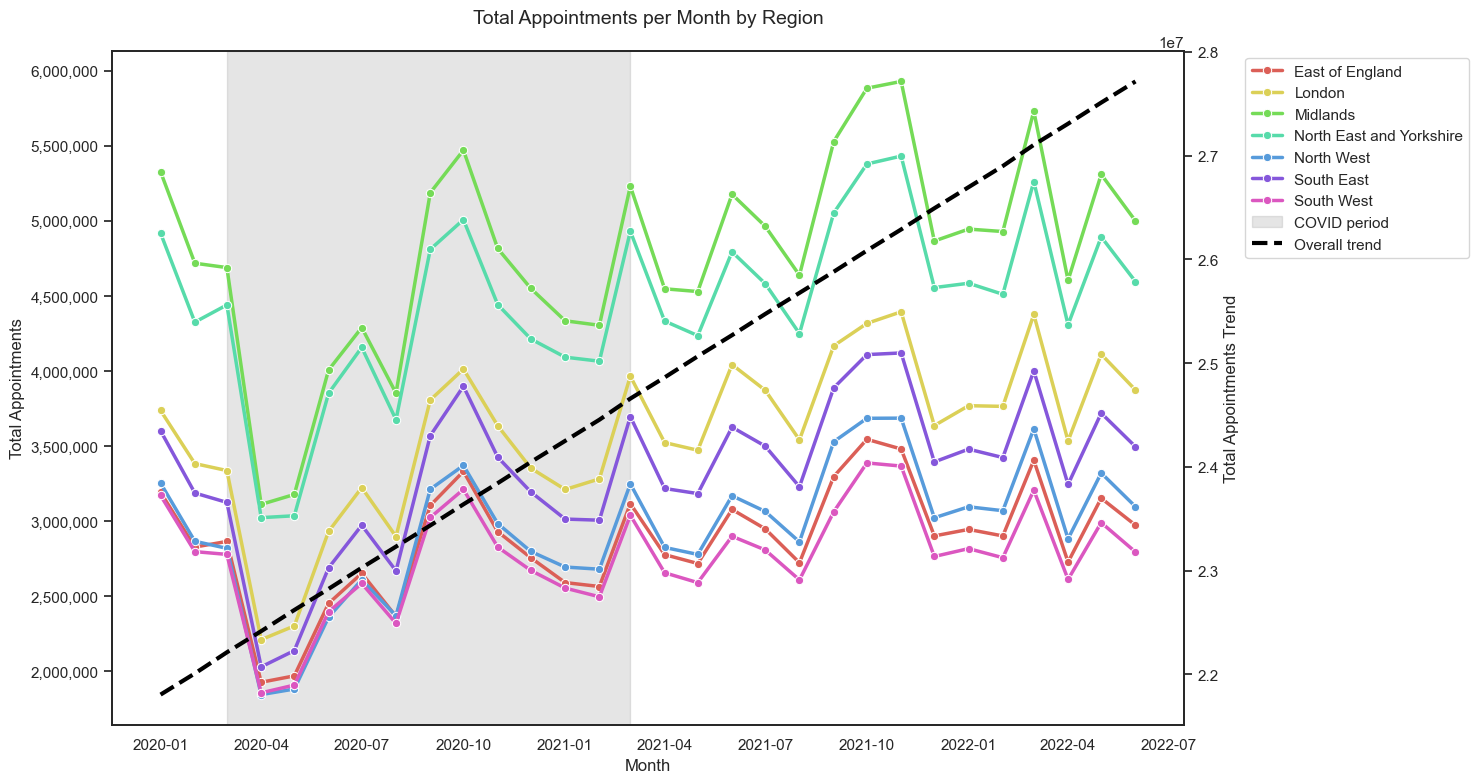

In [38]:
# Plotting time series chart for appointment volume
fig, ax1 = plt.subplots(figsize=(15, 8))

sns.lineplot(
    data=region_appointment,
    x='appointment_month',
    y='count_of_appointments',
    hue='region_name',
    palette='hls',
    linewidth=2.5,
    marker='o',
    errorbar=None,
    ax=ax1
)

# Format primary y-axis
ax1.ticklabel_format(style='plain', axis='y')
ax1.yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
ax1.set_xlabel('Month')
ax1.set_ylabel('Total Appointments')

# Create overall monthly total and trend line
overall = (
    region_appointment
    .groupby('appointment_month', as_index=False)['count_of_appointments']
    .sum()
    .sort_values('appointment_month')
)

# Numeric index for regression
x_num = np.arange(len(overall))
y = overall['count_of_appointments'].values

coef = np.polyfit(x_num, y, 1) 
trend = np.poly1d(coef)
overall['trend'] = trend(x_num)

# Secondary axis (right y-axis) for trend line
ax2 = ax1.twinx() 

ax2.plot(
    overall['appointment_month'],
    overall['trend'],
    color='black',
    linestyle='--',
    linewidth=3,
    label='Overall trend'
)

ax2.set_ylabel('Total Appointments Trend')

# Shading the region to indicate COVID period
covid_start = pd.to_datetime('2020-03-01')
covid_end = pd.to_datetime('2021-03-01')

ax1.axvspan(
    covid_start,
    covid_end,
    color='grey',
    alpha=0.2,
    label='COVID period'
)

# Title and legends
ax1.set_title('Total Appointments per Month by Region', fontsize=14, pad=20)

# Primary legend (regions + COVID band)
handles1, labels1 = ax1.get_legend_handles_labels()
# Secondary legend (trend)
handles2, labels2 = ax2.get_legend_handles_labels()

# Combine legends and place them outside
handles = handles1 + handles2
labels = labels1 + labels2
ax1.legend(handles, labels, bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

In [39]:
# Calculate the average no. of appointments per month per region
avg_appt_region = (
    region_appointment[
        (region_appointment['appointment_month'] >= '2021-04-01') &
        (region_appointment['appointment_month'] <= '2022-06-30')
        ]
    .groupby('region_name')['count_of_appointments']
    .mean()
    .round()
    .astype(int)
    .reset_index(name='avg_month_appt')
    .sort_values(by='avg_month_appt', ascending=False)
)

avg_appt_region

,region_name,avg_month_appt
2,Midlands,5104506
3,North East and Yorkshire,4717111
1,London,3892947
5,South East,3575477
4,North West,3180259
0,East of England,3038537
6,South West,2888396


In [40]:
# Calculate the maximum number of appointments in a month (calculate how much more capacity is needed for the winter pressure
max_appt_region = (
    region_appointment[
        (region_appointment['appointment_month'] >= '2021-04-01') &
        (region_appointment['appointment_month'] <= '2022-06-30')
        ]
    .groupby('region_name')['count_of_appointments']
    .max()
    .reset_index(name='max_month_appt')
    .sort_values(by='max_month_appt', ascending=False)
)
max_appt_region

,region_name,max_month_appt
2,Midlands,5927410
3,North East and Yorkshire,5430475
1,London,4393809
5,South East,4119981
4,North West,3685967
0,East of England,3545285
6,South West,3387851


In [74]:
# Comparing average and maximum stats side by side
appt_min_max = (
    region_appointment[
        (region_appointment['appointment_month'] >= '2021-04-01') &
        (region_appointment['appointment_month'] <= '2022-06-30')
        ]
    .groupby('region_name')['count_of_appointments']
    .agg(
        avg_month_appt='mean',
        max_month_appt='max'
    )
    .round()
    .astype(int)
    .reset_index()
    .sort_values(by='avg_month_appt', ascending=False)
)

appt_min_max

,region_name,avg_month_appt,max_month_appt
2,Midlands,5104506,5927410
3,North East and Yorkshire,4717111,5430475
1,London,3892947,4393809
5,South East,3575477,4119981
4,North West,3180259,3685967
0,East of England,3038537,3545285
6,South West,2888396,3387851


In [42]:
# Number of distinct sub-ICB locations per region
subicb_per_region = (
    location_mapping
    .groupby('region_name')['sub_icb_location_code']
    .nunique()
    .reset_index(name='n_sub_icb_locations')
    .sort_values('n_sub_icb_locations', ascending=False)
).copy()

print(subicb_per_region)

                region_name  n_sub_icb_locations
4                North West                   27
3  North East and Yorkshire                   24
2                  Midlands                   19
0           East of England                   14
5                South East                   12
6                South West                    7
1                    London                    5


##### Observations:
The Midlands region has fewer sub-ICBs than North West (the region with the most sub-ICBs), but has the highest total appointments
North East & Yorkshire has the 2nd highest appointment count and also has the 2nd highest number of sub-ICBs
London has very few sub-ICBs (5) but has the 3rd highest total appointment count.
Regional differences in total appointments and appointments per sub‑ICB reflect underlying differences in population size, population health needs, and how services are organised. In particular, regions such as London, the Midlands, and North East & Yorkshire are expected to show high overall appointment volumes, with London having especially high appointments per sub‑ICB due to its dense population and concentration of services.

#### Exploring the type of primary care services needed per region
The following analysis focuses on the period from 02-Aug-2021 to 30-Jun-2022. This specific window was selected to align with the availability of the national_category dataset. This timeframe is particularly valuable as it captures post-pandemic activity levels, providing a clearer picture of modern service distribution and regional demand than earlier, COVID-impacted datasets. 

In [43]:
# Setting a benchmark for appointment count
nc['count_of_appointments'].sum()

np.int64(296046770)

In [44]:
# Merging with region_lookup for region names
nc_with_regions = pd.merge(
    nc, 
    region_lookup_icb, 
    on='icb_ons_code', 
    how='left'
).copy()

print(nc_with_regions.shape)
print(nc_with_regions['count_of_appointments'].sum())
nc_with_regions.head()

(817394, 12)
296046770


,appointment_date,icb_ons_code,sub_icb_location_name,service_setting,context_type,national_category,count_of_appointments,appointment_month,activity_type,icb_location_name,region_ons_code,region_name
0,2021-08-02,E54000050,NHS North East and North Cumbria ICB - 00L,Primary Care Network,Care Related Encounter,Patient contact during Care Home Round,3,2021-08-01,Care Home & Home Visits,NHS North East and North Cumbria ICB,E40000012,North East and Yorkshire
1,2021-08-02,E54000050,NHS North East and North Cumbria ICB - 00L,Other,Care Related Encounter,Planned Clinics,7,2021-08-01,Planned Reviews & Clinics,NHS North East and North Cumbria ICB,E40000012,North East and Yorkshire
2,2021-08-02,E54000050,NHS North East and North Cumbria ICB - 00L,General Practice,Care Related Encounter,Home Visit,79,2021-08-01,Care Home & Home Visits,NHS North East and North Cumbria ICB,E40000012,North East and Yorkshire
3,2021-08-02,E54000050,NHS North East and North Cumbria ICB - 00L,General Practice,Care Related Encounter,General Consultation Acute,725,2021-08-01,General Consultations,NHS North East and North Cumbria ICB,E40000012,North East and Yorkshire
4,2021-08-02,E54000050,NHS North East and North Cumbria ICB - 00L,General Practice,Care Related Encounter,Structured Medication Review,2,2021-08-01,Planned Reviews & Clinics,NHS North East and North Cumbria ICB,E40000012,North East and Yorkshire


In [45]:
# Grouping by service type
regional_services = (
    nc_with_regions
    .groupby(
        ['service_setting',
         'appointment_month',
         'region_name']
            )['count_of_appointments']
    .sum()
    .reset_index()
).copy()

# View DataFrame
print(regional_services['count_of_appointments'].sum())
print(regional_services.shape)
regional_services.head()

296046770
(385, 4)


,service_setting,appointment_month,region_name,count_of_appointments
0,Extended Access Provision,2021-08-01,East of England,16018
1,Extended Access Provision,2021-08-01,London,42091
2,Extended Access Provision,2021-08-01,Midlands,24545
3,Extended Access Provision,2021-08-01,North East and Yorkshire,22548
4,Extended Access Provision,2021-08-01,North West,13903


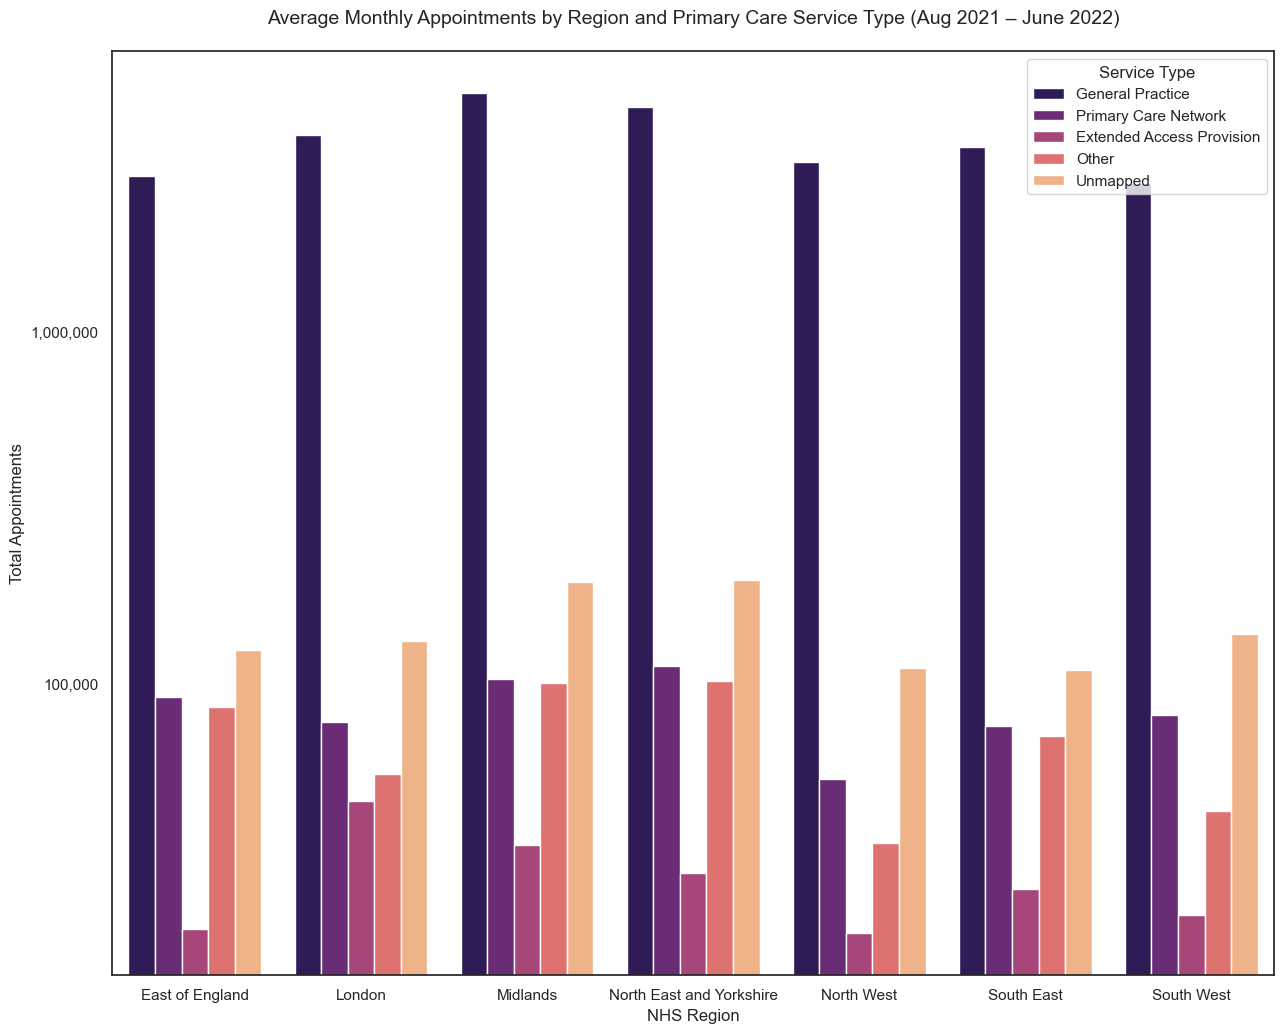

In [46]:
# Cleaning up the order of the legend
legend_order = ['General Practice', 'Primary Care Network', 'Extended Access Provision', 'Other', 'Unmapped']
    
# Create a barplot to show regional services
regional_services_barchart = sns.barplot(
    data=regional_services,
    x='region_name',
    y='count_of_appointments',
    hue='service_setting',
    hue_order=legend_order,
    palette='magma',
    errorbar=None
)

# Apply the Log Scale
regional_services_barchart.set_yscale('log')

# Adding comma dividers
plt.gca().yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

# Adding labels to the chart
plt.title('Average Monthly Appointments by Region and Primary Care Service Type (Aug 2021 – June 2022)', fontsize=14, pad=20)
plt.xlabel('NHS Region')
plt.ylabel('Total Appointments')
plt.legend(title='Service Type')

plt.show()

In [47]:
# Create a heatmap for better visualization
# Group the data to get totals per region and service setting
service_mix = (
    regional_services
    .groupby(['region_name', 'service_setting'])['count_of_appointments']
    .sum()
    .reset_index()
)

print(service_mix['count_of_appointments'].sum())
print(service_mix.shape)
service_mix.head()

296046770
(35, 3)


,region_name,service_setting,count_of_appointments
0,East of England,Extended Access Provision,220387
1,East of England,General Practice,30515758
2,East of England,Other,941656
3,East of England,Primary Care Network,1006857
4,East of England,Unmapped,1370389


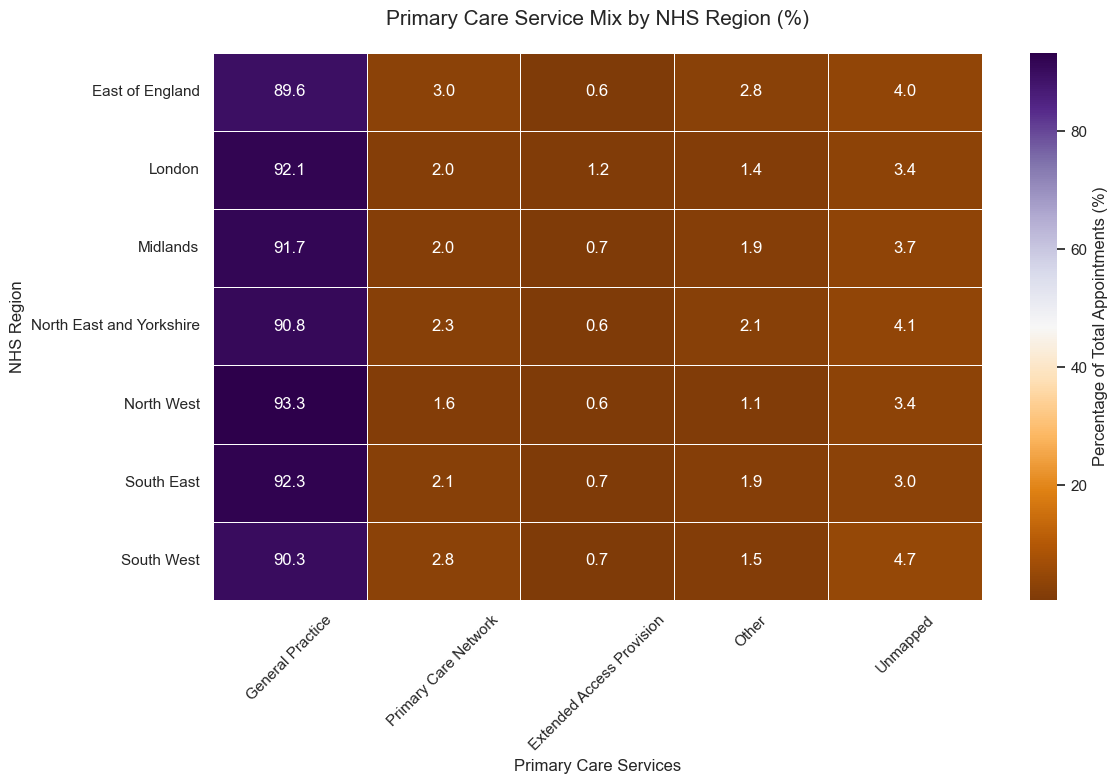

In [48]:
# Defining the order of service_settings displayed
ordered_service_setting = [
    'General Practice', 
    'Primary Care Network', 
    'Extended Access Provision', 
    'Other', 
    'Unmapped'
]

# Pivot the table so regions are on the Y-axis and service types on the X-axis
pivot_df = service_mix.pivot(
    index='region_name', 
    columns='service_setting', 
    values='count_of_appointments'
)

# Reindex the columns to follow ordered_service_setting list
pivot_df = pivot_df.reindex(columns=ordered_service_setting)

# Convert to percentages (Divide each row by the row's total)
percentage_mix = pivot_df.div(pivot_df.sum(axis=1), axis=0) * 100

# 4. Create the Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(
    percentage_mix, 
    annot=True,          # Show the numbers in the boxes
    fmt=".1f",           # Format to 1 decimal place
    cmap="PuOr",
    linewidths=.5,
    cbar_kws={'label': 'Percentage of Total Appointments (%)'}
)

plt.title('Primary Care Service Mix by NHS Region (%)', fontsize=15, pad=20)
plt.ylabel('NHS Region')
plt.xlabel('Primary Care Services')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [49]:
# Closer look into gp's activities 
at = (
    nc_with_regions[
        (nc_with_regions['service_setting'] == 'General Practice') &
        (nc_with_regions['activity_type'] != 'Inconsistent Mapping / Data Quality')
        ]   
        .groupby(
            [
                'appointment_month',
                'region_name',
                'activity_type'
            ])['count_of_appointments']
        .sum()
        .reset_index()
)
print(nc_with_regions['count_of_appointments'].sum())
print(nc_with_regions.isna().sum())
at.head()

296046770
appointment_date         0
icb_ons_code             0
sub_icb_location_name    0
service_setting          0
context_type             0
national_category        0
count_of_appointments    0
appointment_month        0
activity_type            0
icb_location_name        0
region_ons_code          0
region_name              0
dtype: int64


,appointment_month,region_name,activity_type,count_of_appointments
0,2021-08-01,East of England,Care Home & Home Visits,25281
1,2021-08-01,East of England,General Consultations,1750834
2,2021-08-01,East of England,Group & Social Support,2894
3,2021-08-01,East of England,Planned Reviews & Clinics,456969
4,2021-08-01,East of England,Unplanned & Walk-In Activity,38154


In [50]:
# Average no. of appointments per month
at_avg = (
    at.groupby(['region_name', 'activity_type'])['count_of_appointments']
    .mean() # Important to calculate mean in a separate df as it would've otherwise calculated the average per row
    .reset_index()
)
at_avg.head()

,region_name,activity_type,count_of_appointments
0,East of England,Care Home & Home Visits,3.206191e+04
1,East of England,General Consultations,1.903236e+06
2,East of England,Group & Social Support,3.654909e+03
3,East of England,Planned Reviews & Clinics,6.013336e+05
4,East of England,Unplanned & Walk-In Activity,4.399064e+04


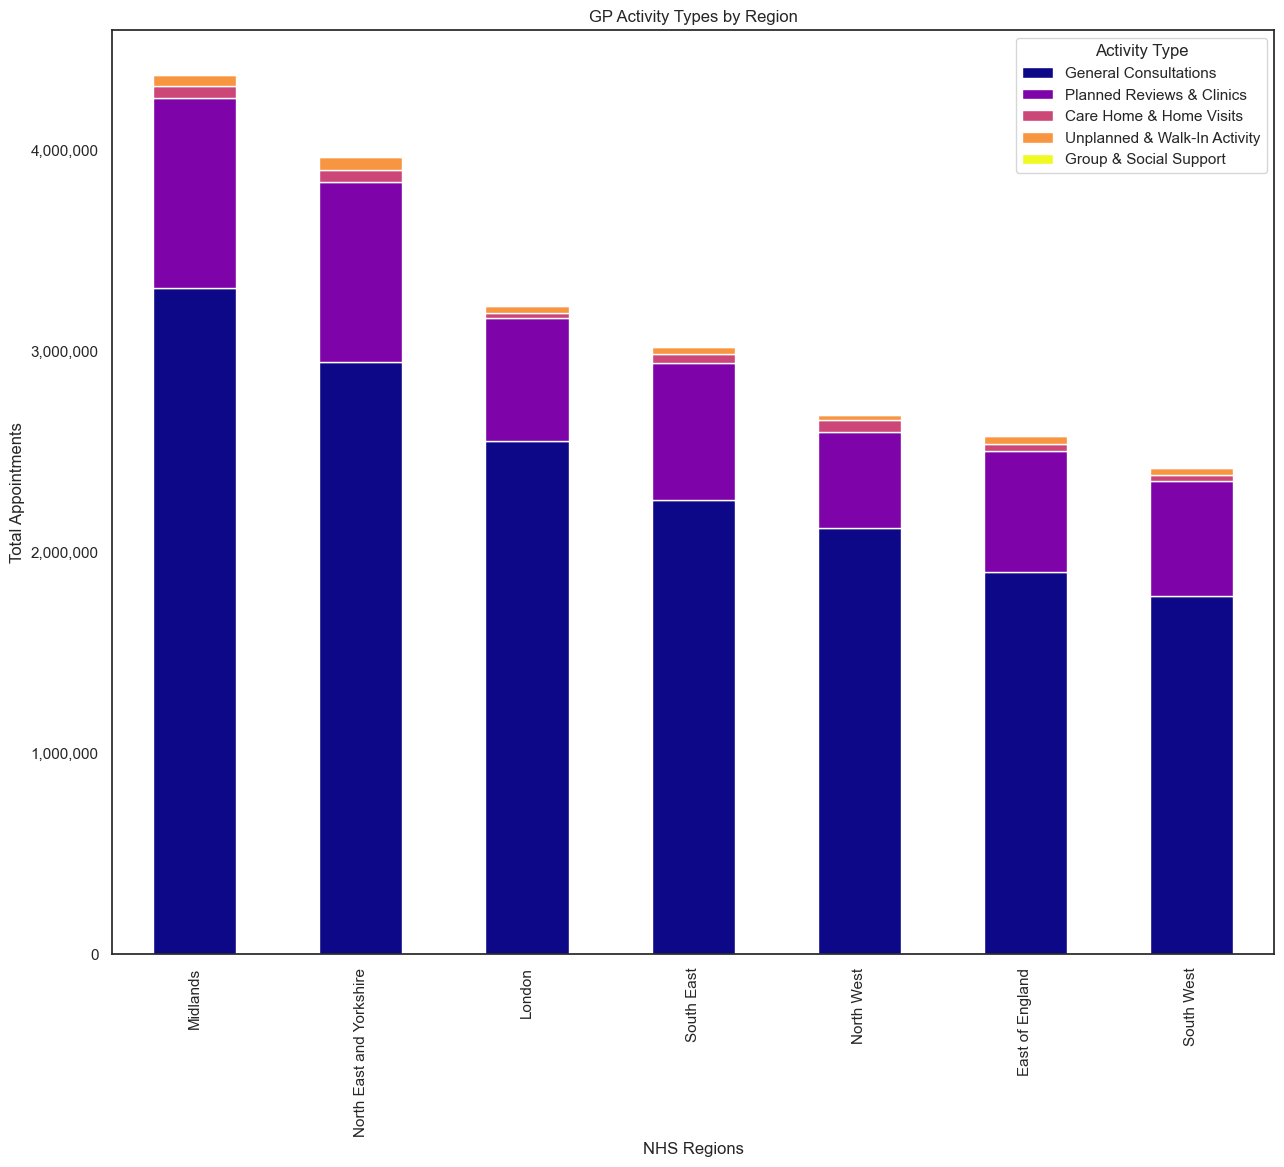

In [51]:
# GP Activity Type Mix per Region
# Setting the region order
pivot_at = at_avg.pivot(
    index='region_name',
    columns='activity_type',
    values='count_of_appointments'
)

pivot_at['row_total'] = pivot_at.sum(axis=1)
pivot_at = pivot_at.sort_values(by='row_total', ascending=False).drop(columns='row_total')

col_order = pivot_at.sum(axis=0).sort_values(ascending=False).index
pivot_at = pivot_at[col_order]

ax = pivot_at.plot(kind='bar', stacked=True, colormap='plasma')

ax.yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

plt.title('GP Activity Types by Region')
plt.ylabel('Total Appointments')
plt.xlabel('NHS Regions')
plt.legend(title='Activity Type')
plt.show()

#### Exploring Appointment Volume Trends Across the Highest-Activity Regions Over Time: Midlands, NE & Yorkshire, and London

In [52]:
# Subsetting the General Practice service
# Define the filter
gp_services = (
    regional_services[
        (regional_services['region_name'].isin(['Midlands', 'London', 'North East and Yorkshire'])) & 
        (regional_services['service_setting'] == 'General Practice')
    ].copy()
)

gp_services.head()

,service_setting,appointment_month,region_name,count_of_appointments
78,General Practice,2021-08-01,London,3218146
79,General Practice,2021-08-01,Midlands,4183384
80,General Practice,2021-08-01,North East and Yorkshire,3824091
85,General Practice,2021-09-01,London,3801350
86,General Practice,2021-09-01,Midlands,5022534


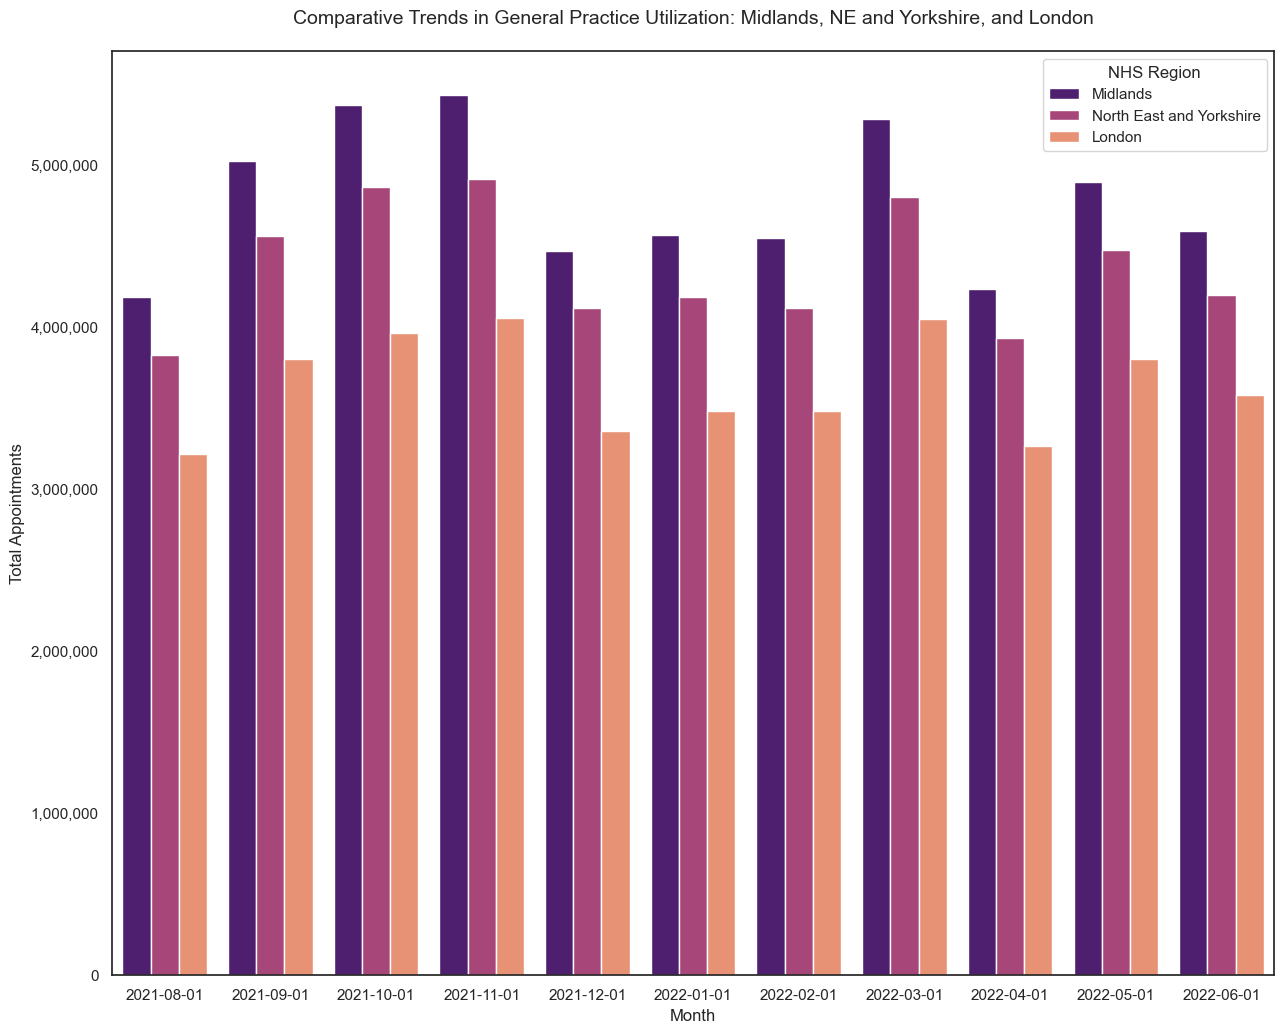

In [53]:
# Cleaning up the order of the legend
legend_order = ['Midlands', 'North East and Yorkshire', 'London']
    
# Create a barplot to show regional services
sns.barplot(
    data=gp_services,
    x='appointment_month',
    y='count_of_appointments',
    hue='region_name',
    hue_order=legend_order,
    palette='magma',
    errorbar=None
)

# Adding comma dividers
plt.gca().yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

# Adding labels to the chart
plt.title('Comparative Trends in General Practice Utilization: Midlands, NE and Yorkshire, and London', fontsize=14, pad=20)
plt.xlabel('Month')
plt.ylabel('Total Appointments')
plt.legend(title='NHS Region')

plt.show()

##### Observations from the Comparative Trends in General Practice Utilization chart:
- Consistent 'M-shaped' seasonal pulse across all 3 regions
- August to November showcases a steady incremental increase in appointment volumes, peaking in November. This aligns with the return to schools and the onset of the viral respiratory season, driving higher clinical demand
- December sees a sharp decline in total appointments; this is potentially due to a reduction in operational capacity over the holidays
- Appointment volumes surge again from January onwards to March, potentially reflecting the 'rebound' effect of deferred December demand combined with peak winter illnness, and the administrative push to complete clinical reviews before the end of the NHS fiscal year in March
- Similar to the December decline, the drop in April suggests the impact of the Easter holiday period on service availability. 

### Exploratory Analysis of Attendance Rates, Appointment Modes and Wait Time

#### Exploring Attendance Rates across NHS Regions

In [54]:
# Visualizing Attended Appointments vs Missed Appointments 
# Specifying for post covid time period
status_with_regions = (
    ar_with_regions[
        (ar_with_regions['appointment_month'] >= '2021-04-01') &
        (ar_with_regions['appointment_month'] <= '2022-06-30')
        ]
    .groupby(
        ['appointment_month',
         'region_name',
         'appointment_status'
        ])
    ['count_of_appointments']
    .sum()
    .reset_index()
)

print(status_with_regions.isna().sum())
status_with_regions.head(21)

appointment_month        0
region_name              0
appointment_status       0
count_of_appointments    0
dtype: int64


,appointment_month,region_name,appointment_status,count_of_appointments
0,2021-04-01,East of England,Attended,2598683
1,2021-04-01,East of England,DNA,81392
2,2021-04-01,East of England,Unknown,97421
3,2021-04-01,London,Attended,3224908
4,2021-04-01,London,DNA,154586
5,2021-04-01,London,Unknown,143939
6,2021-04-01,Midlands,Attended,4193649
7,2021-04-01,Midlands,DNA,181768
8,2021-04-01,Midlands,Unknown,171637
9,2021-04-01,North East and Yorkshire,Attended,4036842


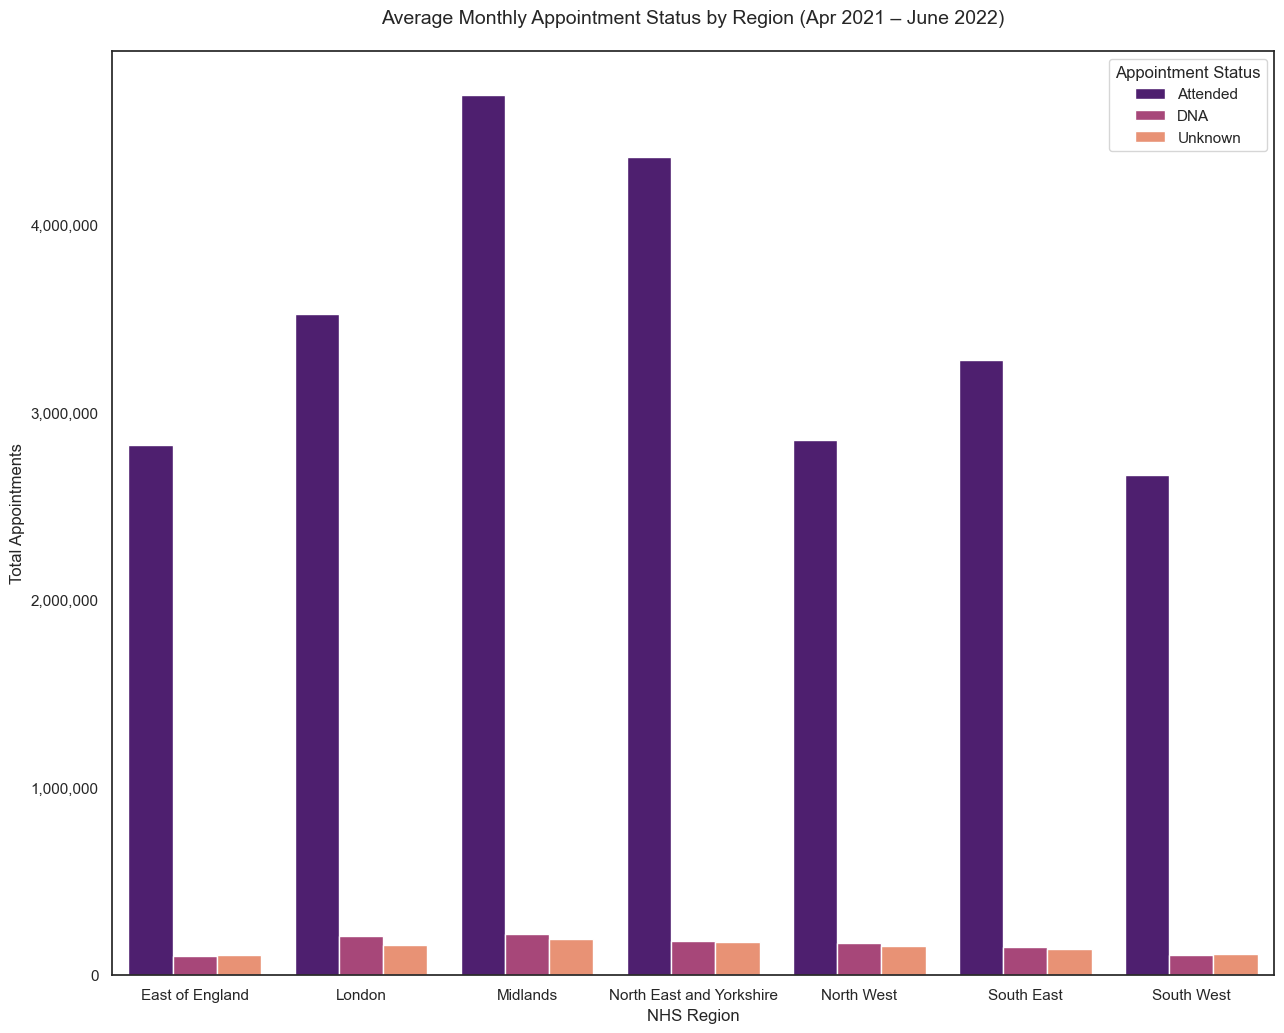

In [55]:
# Cleaning up the order of the legend
status_legend = ['Attended', 'DNA', 'Unknown']
    
# Create a barplot to show regional services
sns.barplot(
    data=status_with_regions,
    x='region_name',
    y='count_of_appointments',
    hue='appointment_status',
    hue_order=status_legend,
    palette='magma',
    errorbar=None
)

# Adding comma dividers
plt.gca().yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

# Adding labels to the chart
plt.title('Average Monthly Appointment Status by Region (Apr 2021 – June 2022)', fontsize=14, pad=20)
plt.xlabel('NHS Region')
plt.ylabel('Total Appointments')
plt.legend(title='Appointment Status')

plt.show()


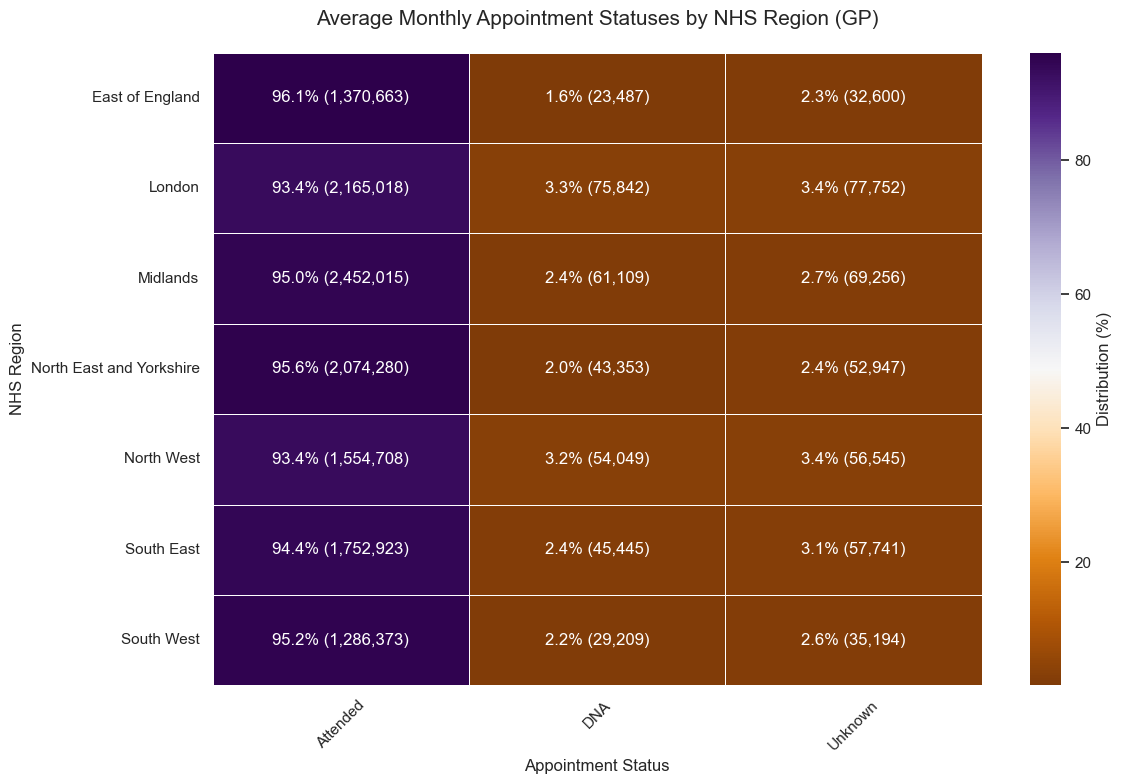

In [56]:
# Creating a heatmap for better visualization
monthly_gp_totals = (
    ar_with_regions[
        (ar_with_regions['appointment_month'] >= '2021-04-01') &
        (ar_with_regions['appointment_month'] <= '2022-06-30') &
        (ar_with_regions['hcp_type'] == 'GP')
        ]
    .groupby(
        [
            'appointment_month',
            'appointment_status',
            'region_name'
        ]
         )['count_of_appointments']
    .sum()
    .reset_index()
)

# Calculate the mean of monthly totals
status_heatmap = (
    monthly_gp_totals
    .groupby(
        ['region_name', 'appointment_status']
    )['count_of_appointments']
    .mean()
    .reset_index()
)
         
# Defining the order of service_settings displayed
ordered_appointment_status = [
    'Attended',
    'DNA',
    'Unknown'
]


# Pivot the table so regions are on the Y-axis and service types on the X-axis
status_pivot = status_heatmap.pivot(
    index='region_name', 
    columns='appointment_status', 
    values='count_of_appointments'
)

# Reindex the columns to follow ordered_service_setting list
status_pivot = status_pivot.reindex(columns=ordered_appointment_status)

# Convert to percentages (Divide each row by the row's total)
status_region_percentage = status_pivot.div(status_pivot.sum(axis=1), axis=0) * 100

# Include appointment counts in the label
annot_labels = status_region_percentage.round(1).astype(str) + "% (" + \
    status_pivot.applymap(lambda x: f"{int(x):,}") + ")"

# 4. Create the Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(
    status_region_percentage, 
    annot=annot_labels,          
    fmt="",           
    cmap="PuOr",
    linewidths=.5,
    cbar_kws={'label': 'Distribution (%)'}
)

plt.title('Average Monthly Appointment Statuses by NHS Region (GP)', fontsize=15, pad=20)
plt.ylabel('NHS Region')
plt.xlabel('Appointment Status')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

##### Observations:
- Having the highest appointment volume does not neccessarily mean the region also has the highest Did Not Attend Rate
- The heatmap has shown us that despite ranking second highest in overall appointment volume, North East & Yorkshire has the third lowest DNA rates across the regions
- North West, on the other hand, also has a disproportionately high DNA rate
- Interesting now to ask what causes DNA statuses?

#### Drilling into ICB and Sub-ICB locations 

In [57]:
# Include ICB locations into the filter
status_barchart = (
    ar_with_regions[
        (ar_with_regions['appointment_month'] >= '2021-04-01') &
        (ar_with_regions['appointment_month'] <= '2022-06-30') &
        (ar_with_regions['hcp_type'] == 'GP')
        ]
    .groupby(
        [
            'appointment_status',
            'region_name',
            'icb_ons_code',
            'icb_location_name'
        ]
         )['count_of_appointments']
    .sum()
    .reset_index()
)

status_barchart.head()

,appointment_status,region_name,icb_ons_code,icb_location_name,count_of_appointments
0,Attended,East of England,E54000022,NHS Norfolk and Waveney ICB,3105673
1,Attended,East of England,E54000023,NHS Suffolk and North East Essex ICB,2874291
2,Attended,East of England,E54000024,"NHS Bedfordshire, Luton and Milton Keynes ICB",3024356
3,Attended,East of England,E54000025,NHS Hertfordshire and West Essex ICB,5113249
4,Attended,East of England,E54000026,NHS Mid and South Essex ICB,3532641


In [58]:
# Stacked Bar Chart for ICB locations with average monthly DNAs
icb_dna_avg = (
    status_barchart[
        (status_barchart['appointment_status'] == 'DNA')
        ]
    .groupby(['region_name', 'appointment_status', 'icb_location_name'])['count_of_appointments']
    .mean()
    .reset_index()
    .sort_values(by='count_of_appointments', ascending=False)
)
icb_dna_avg.head(10)

,region_name,appointment_status,icb_location_name,count_of_appointments
27,North West,DNA,NHS Greater Manchester ICB,363897.0
26,North West,DNA,NHS Cheshire and Merseyside ICB,294319.0
7,London,DNA,NHS North East London ICB,256358.0
9,London,DNA,NHS South East London ICB,240376.0
8,London,DNA,NHS North West London ICB,237697.0
23,North East and Yorkshire,DNA,NHS North East and North Cumbria ICB,223759.0
10,London,DNA,NHS South West London ICB,212325.0
6,London,DNA,NHS North Central London ICB,190888.0
32,South East,DNA,NHS Kent and Medway ICB,174094.0
12,Midlands,DNA,NHS Black Country ICB,162029.0


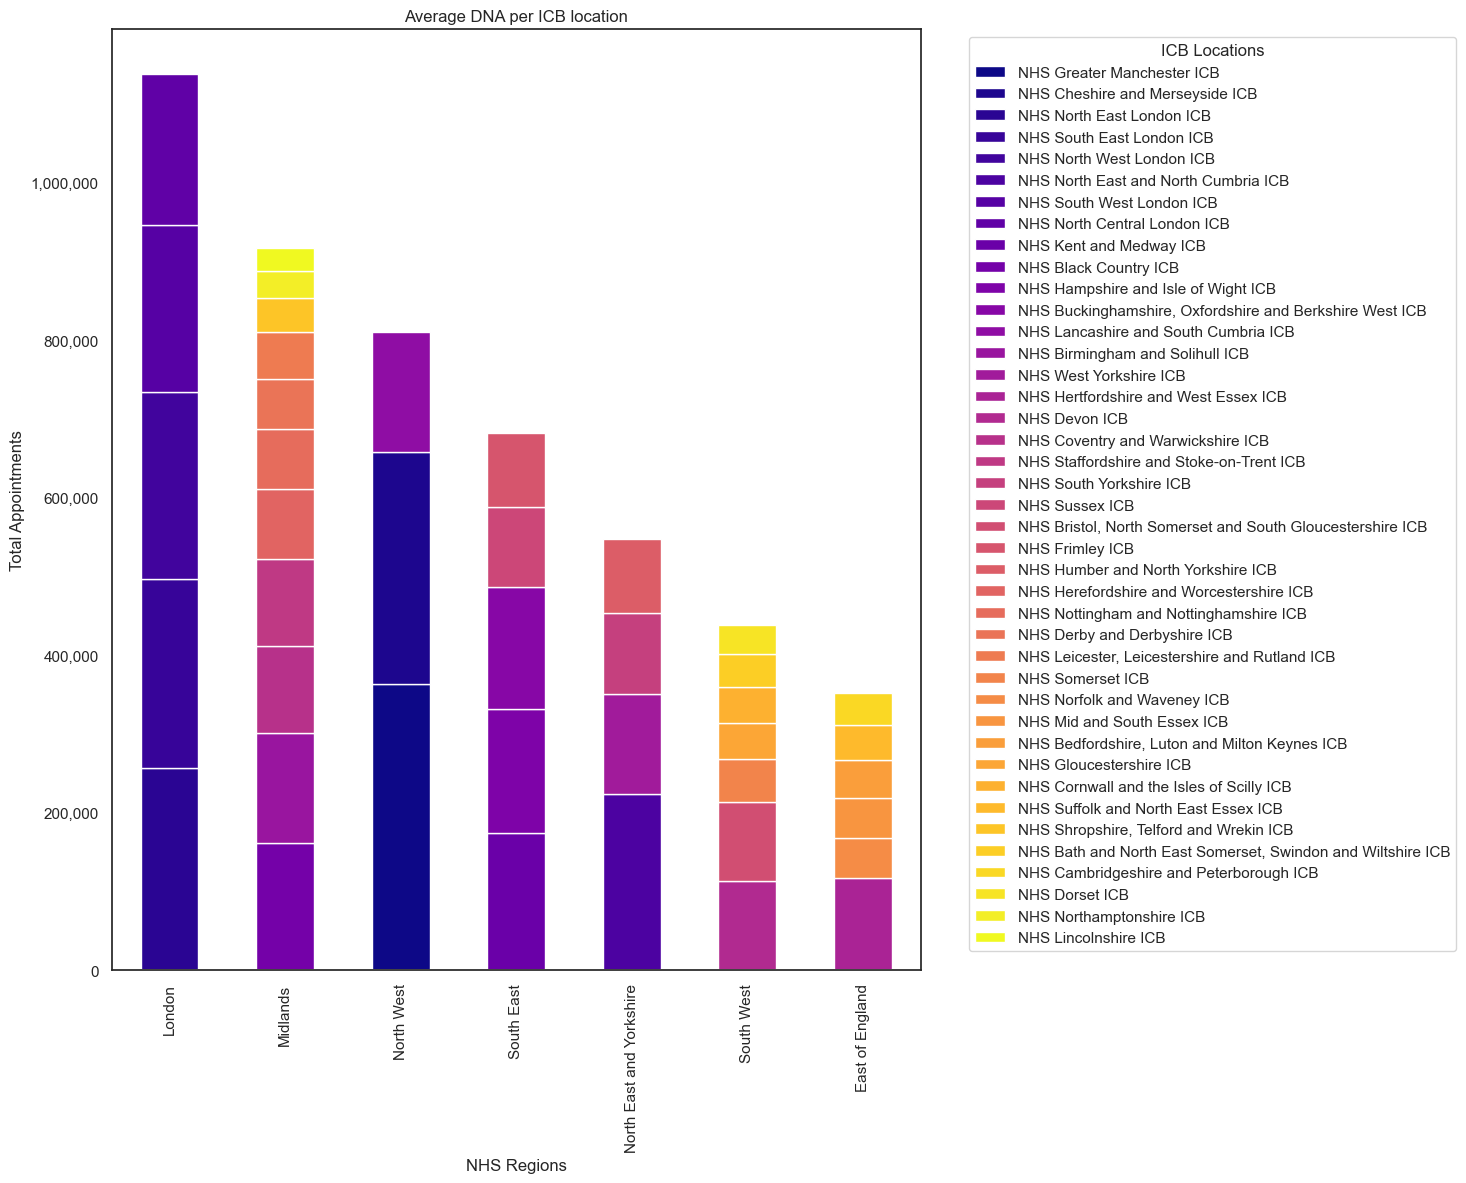

In [59]:
# Pivot the icb_dna_avg table
pivot_icb_dna_avg = icb_dna_avg.pivot(
    index='region_name',
    columns='icb_location_name',
    values='count_of_appointments'
)

# Plotting the stacked bar chart
pivot_icb_dna_avg['row_total'] = pivot_icb_dna_avg.sum(axis=1)
pivot_icb_dna_avg = pivot_icb_dna_avg.sort_values(by='row_total', ascending=False).drop(columns='row_total')

col_order = pivot_icb_dna_avg.sum(axis=0).sort_values(ascending=False).index
pivot_icb_dna_avg = pivot_icb_dna_avg[col_order]

ax = pivot_icb_dna_avg.plot(kind='bar', stacked=True, colormap='plasma')

ax.yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

plt.title('Average DNA per ICB location')
plt.ylabel('Total Appointments')
plt.xlabel('NHS Regions')
plt.legend(title='ICB Locations')
plt.legend(title='ICB Locations', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

#### Investigating for patterns or trends between appointment statuses and appointment modes

In [60]:
# Create dataframe for sum appointment modes & appointment status - am
am = (
    ar_with_regions[
        (ar_with_regions['appointment_month'] >= '2021-04-01')
        & (ar_with_regions['appointment_month'] <= '2022-06-30')
        & (ar_with_regions['appointment_status'] != 'Unknown')
        & (ar_with_regions['appointment_mode'] != 'Unknown')
    ]
    .groupby(
        [
            'appointment_status',
            'appointment_mode',
            'appointment_month'
        ]
    )['count_of_appointments']
    .sum()
    .reset_index()
).copy()

am.head()

,appointment_status,appointment_mode,appointment_month,count_of_appointments
0,Attended,Face-to-Face,2021-04-01,11816844
1,Attended,Face-to-Face,2021-05-01,11856300
2,Attended,Face-to-Face,2021-06-01,13689479
3,Attended,Face-to-Face,2021-07-01,13240757
4,Attended,Face-to-Face,2021-08-01,12486211


In [61]:
# Calculate percentage of total for each mode
mode_counts = am.groupby(['appointment_mode', 'appointment_status'])['count_of_appointments'].sum()
total_mode_appointments = mode_counts.sum()

mode_percentages = (mode_counts / total_mode_appointments) * 100

print(total_mode_appointments)
print(mode_counts)
print(mode_percentages)

369027317
appointment_mode  appointment_status
Face-to-Face      Attended              215127881
                  DNA                    13642164
Home Visit        Attended                1965370
                  DNA                      104101
Telephone         Attended              133368603
                  DNA                     2871706
Video/Online      Attended                1849961
                  DNA                       97531
Name: count_of_appointments, dtype: int64
appointment_mode  appointment_status
Face-to-Face      Attended              58.295923
                  DNA                    3.696790
Home Visit        Attended               0.532581
                  DNA                    0.028210
Telephone         Attended              36.140577
                  DNA                    0.778182
Video/Online      Attended               0.501307
                  DNA                    0.026429
Name: count_of_appointments, dtype: float64


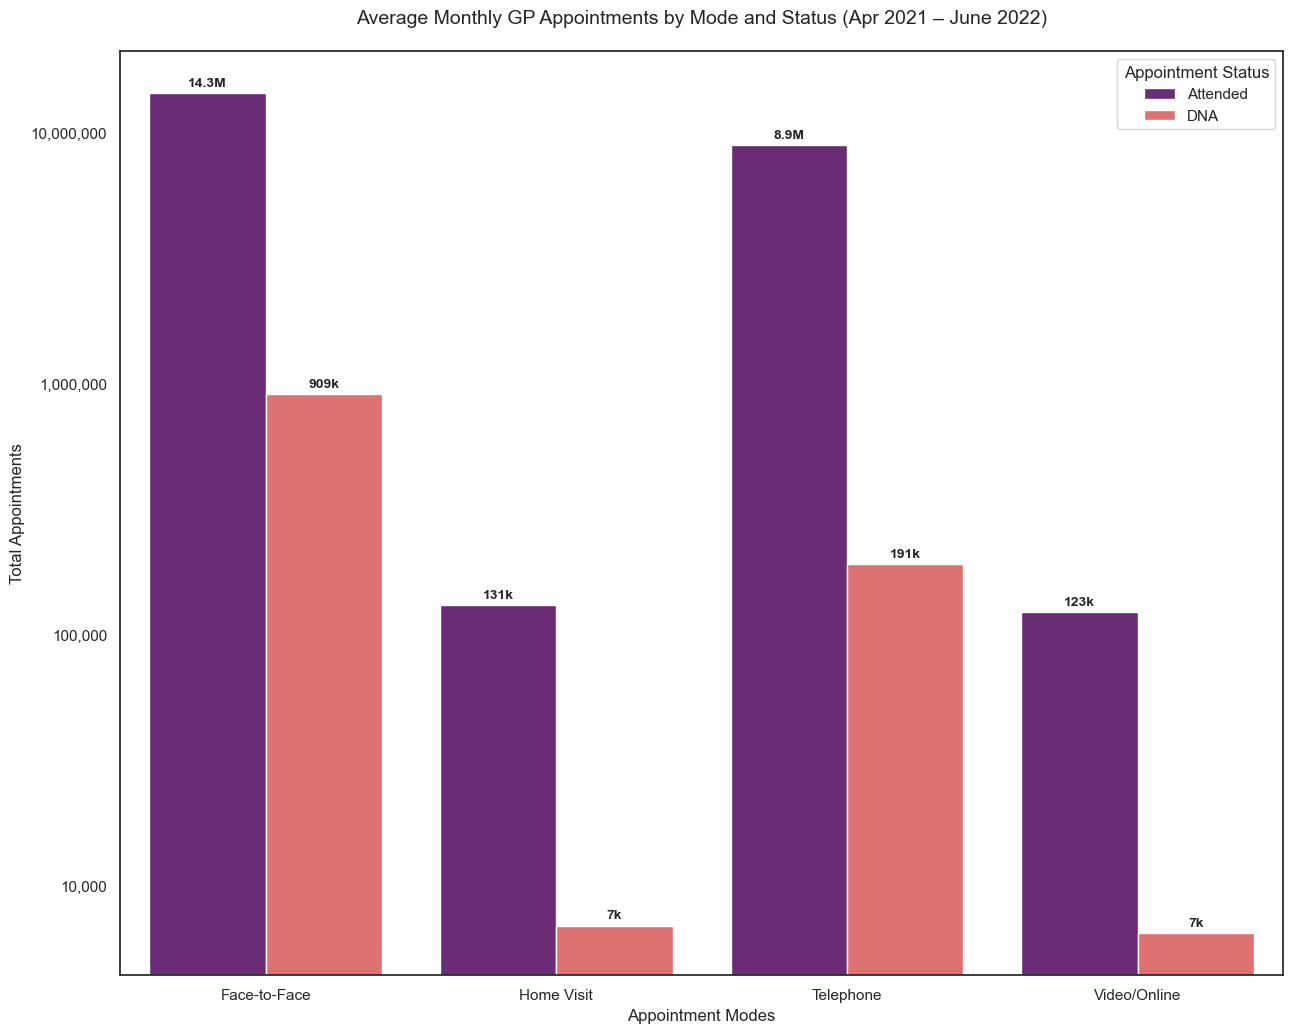

In [62]:
# Grouped bar chart for appointment modes
# Cleaning up the order of the legend
status_legend = ['Attended','DNA']
    
# Create a barplot to show regional services
am_barchart = sns.barplot(
    data=am,
    x='appointment_mode',
    y='count_of_appointments',
    hue='appointment_status',
    hue_order=status_legend,
    palette='magma',
    errorbar=None
)

# Apply the Log Scale
am_barchart.set_yscale('log')

# Add bar labels using a loop
def format_label(value):
    if value >= 1_000_000: return f'{value/1_000_000:.1f}M'
    elif value >= 1_000: return f'{value/1_000:.0f}k'
    return f'{value:.0f}'

for container in am_barchart.containers:
    labels = [format_label(v) for v in container.datavalues]
    am_barchart.bar_label(container, labels=labels, padding=3, fontsize=10, fontweight='bold')

# Add comma dividers
plt.gca().yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

# Adding labels to the chart
plt.title('Average Monthly GP Appointments by Mode and Status (Apr 2021 – June 2022)', fontsize=14, pad=20)
plt.xlabel('Appointment Modes')
plt.ylabel('Total Appointments')
plt.legend(title='Appointment Status')

plt.show()


#### Investigating whether DNA status volumes change over time across different appointment modes

In [63]:
# Create dataframe for appointment modes to identify trends over time
am_dna = (
    ar_with_regions[
        (ar_with_regions['appointment_month'] >= '2021-04-01')
        & (ar_with_regions['appointment_month'] <= '2022-06-30')
        & (ar_with_regions['appointment_status'] == 'DNA')
        & (ar_with_regions['appointment_mode'] != 'Unknown')
    ]
    .groupby(
        [
            'appointment_status',
            'appointment_mode',
            'appointment_month'
        ]
    )['count_of_appointments']
    .sum()
    .reset_index()
).copy()

am_dna.head()

,appointment_status,appointment_mode,appointment_month,count_of_appointments
0,DNA,Face-to-Face,2021-04-01,667714
1,DNA,Face-to-Face,2021-05-01,657659
2,DNA,Face-to-Face,2021-06-01,772491
3,DNA,Face-to-Face,2021-07-01,782278
4,DNA,Face-to-Face,2021-08-01,726087


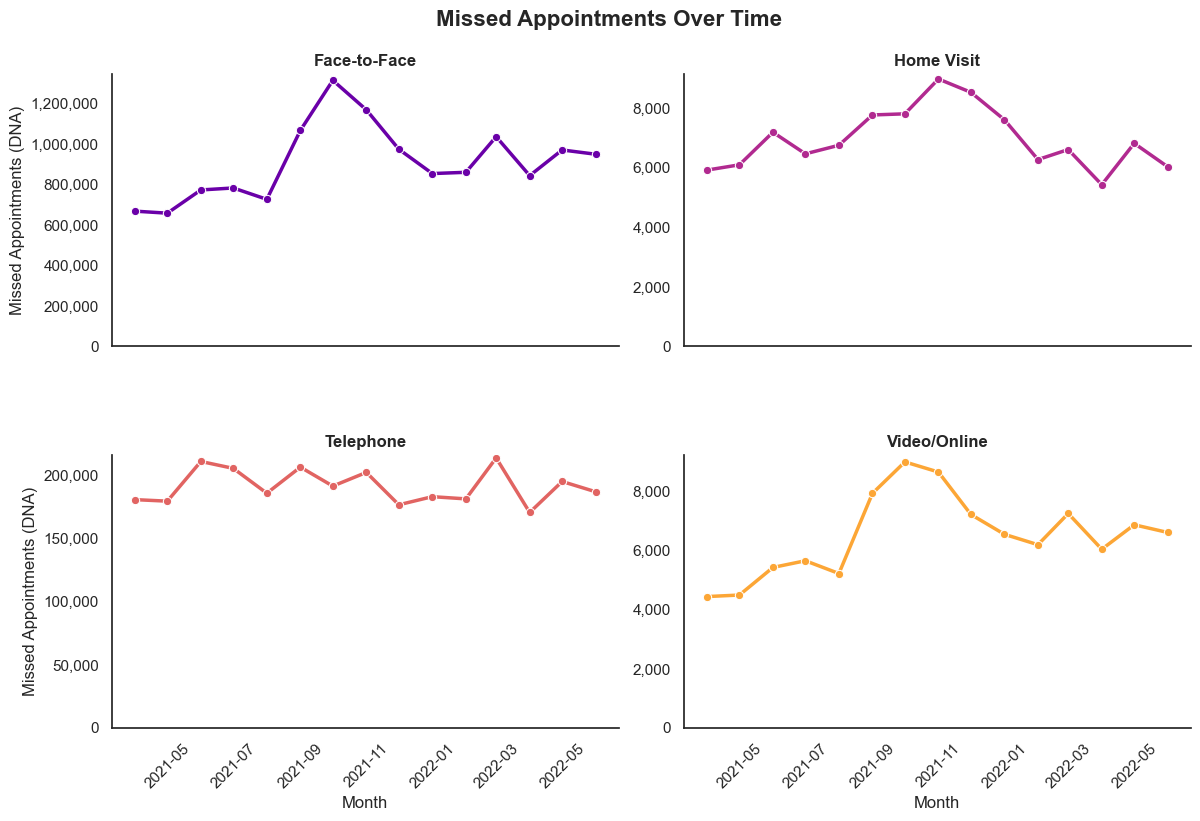

In [64]:
# Create multiple charts instead of merging as the scale difference between each mode is too great
# Create the Grid (col_wrap=2 means 2 charts per row)
g = sns.FacetGrid(
    am_dna, 
    col="appointment_mode", 
    col_wrap=2, 
    sharey=False, 
    height=4, 
    aspect=1.5, 
    hue="appointment_mode", 
    palette="plasma"
)

# Map the Lineplot to the Grid
g.map(sns.lineplot,
      "appointment_month",
      "count_of_appointments",
      linewidth=2.5,
      marker='o'
     )

# Customizing each subplot for professional presentation
for ax in g.axes.flat:
    # Ensure y-axis starts at 0
    ax.set_ylim(0, None)
    
    # Format Y-axis with commas for thousands/millions
    ax.yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
    
    # Rotate X-axis month labels for clarity
    for label in ax.get_xticklabels():
        label.set_rotation(45)
    
    # Remove the redundant "appointment_mode =" from the titles
    if ax.get_title():
        new_title = ax.get_title().split('=')[-1].strip()
        ax.set_title(new_title, fontweight='bold', fontsize=12)

# Clean up the axis labels (Rotation and Formatting)
for ax in g.axes.flat:
    ax.yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
    plt.setp(ax.get_xticklabels(), rotation=45)

g.set_axis_labels("Month", "Missed Appointments (DNA)")
plt.subplots_adjust(top=0.9, hspace=0.4)
g.fig.suptitle('Missed Appointments Over Time', fontsize=16, fontweight='bold')

plt.show()

#### Exploring the impacts of Wait Time (time_between_book_and_appointment) on Appointment Statuses

In [65]:
# Create dataframe for wait time
wait_time = (
        ar_with_regions[
        (ar_with_regions['appointment_month'] >= '2021-04-01')
        & (ar_with_regions['appointment_month'] <= '2022-06-30')
        & (ar_with_regions['appointment_status'] != 'Unknown')
        & (ar_with_regions['time_between_book_and_appointment'] != 'Unknown / Data Quality')
            ]
    .groupby(
        [
            'appointment_month',
            'appointment_status',
            'time_between_book_and_appointment'
        ]
    )['count_of_appointments']
    .sum()
    .reset_index()
).copy()

print(wait_time.isna().sum())
wait_time.head()

appointment_month                    0
appointment_status                   0
time_between_book_and_appointment    0
count_of_appointments                0
dtype: int64


,appointment_month,appointment_status,time_between_book_and_appointment,count_of_appointments
0,2021-04-01,Attended,1 Day,2142128
1,2021-04-01,Attended,15 to 21 Days,1137241
2,2021-04-01,Attended,2 to 7 Days,4675017
3,2021-04-01,Attended,22 to 28 Days,603100
4,2021-04-01,Attended,8 to 14 Days,2583519


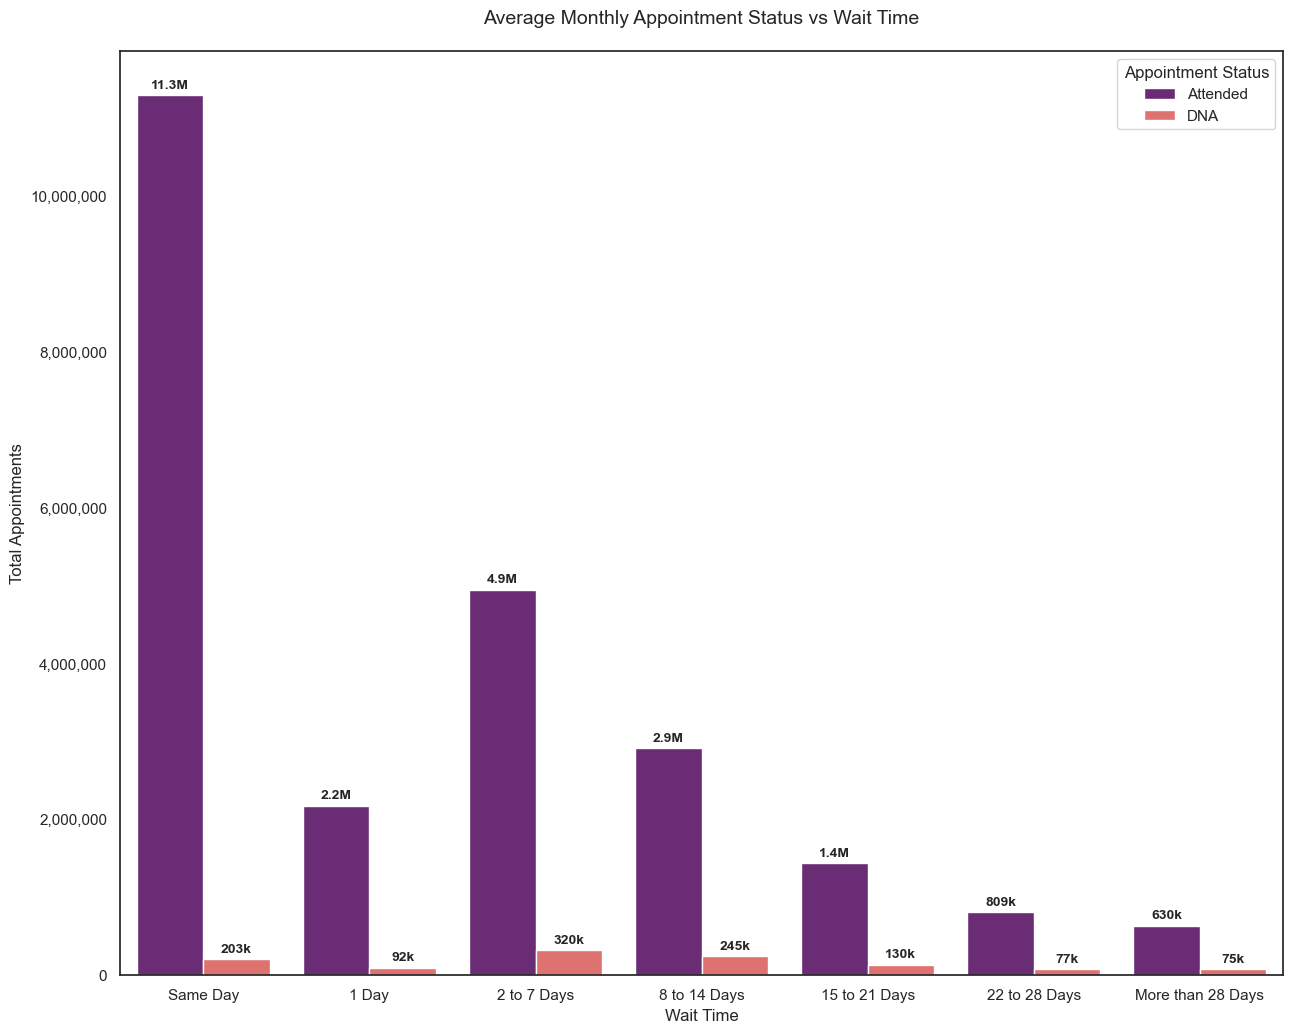

In [66]:
# Grouped bar chart for time_between_book_and_appointment
# Specify the x-axis order
wait_order = [
    'Same Day', 
    '1 Day', 
    '2 to 7 Days', 
    '8 to 14 Days',
    '15 to 21 Days', 
    '22 to 28 Days',  
    'More than 28 Days'
]

# Create a barplot to show regional services
wait_time_barchart = sns.barplot(
    data=wait_time,
    x='time_between_book_and_appointment',
    y='count_of_appointments',
    hue='appointment_status',
    palette='magma',
    order=wait_order,
    errorbar=None
)

# Add bar labels using a loop
def format_label(value):
    if value >= 1_000_000: return f'{value/1_000_000:.1f}M'
    elif value >= 1_000: return f'{value/1_000:.0f}k'
    return f'{value:.0f}'

for container in wait_time_barchart.containers:
    labels = [format_label(v) for v in container.datavalues]
    wait_time_barchart.bar_label(container, labels=labels, padding=3, fontsize=10, fontweight='bold')

# Add comma dividers
plt.gca().yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

# Adding labels to the chart
plt.title('Average Monthly Appointment Status vs Wait Time', fontsize=14, pad=20)
plt.xlabel('Wait Time')
plt.ylabel('Total Appointments')
plt.legend(title='Appointment Status')

plt.show()

In [67]:
# Pivot to get Attended and DNA as columns
scatter_data = wait_time.pivot_table(
    index=['appointment_month', 'time_between_book_and_appointment'], 
    columns='appointment_status', 
    values='count_of_appointments'
).reset_index()

# Calculate the DNA Rate (The "Y" Variable)
scatter_data['DNA_Rate'] = (scatter_data['DNA'] / (scatter_data['DNA'] + scatter_data['Attended'])) * 100

# Map Categories to Numbers (The "X" Variable)
# Use the midpoint of the days to create a linear scale
wait_mapping = {
    'Same Day': 0,
    '1 Day': 1,
    '2 to 7 Days': 4.5,      # Midpoint of 2-7
    '8 to 14 Days': 11,     # Midpoint of 8-14
    '15 to 21 Days': 18,    # Midpoint of 15-21
    '22 to 28 Days': 25,    # Midpoint of 22-28
    'More than 28 Days': 35  # Estimated average for 28+
}
scatter_data['wait_days'] = scatter_data['time_between_book_and_appointment'].map(wait_mapping)

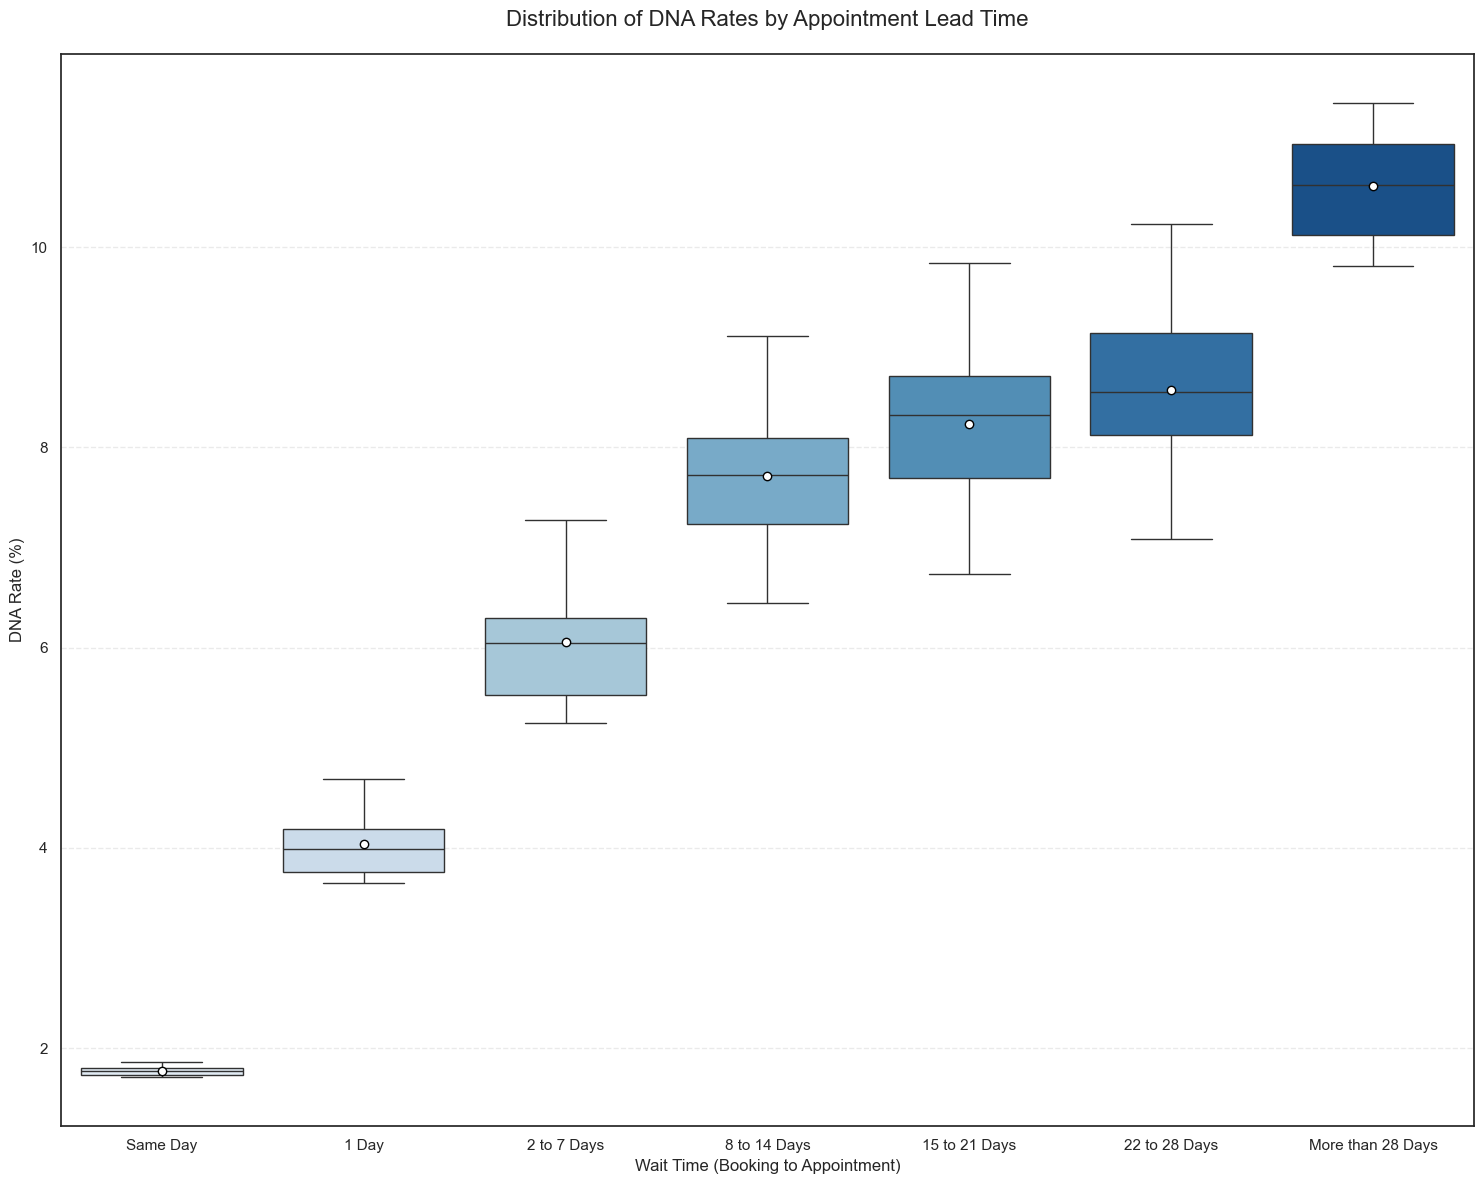

In [68]:
# Plotting a boxplot for DNA Rates across Wait Time categories
ordered_wait_times = [
    'Same Day', 
    '1 Day', 
    '2 to 7 Days', 
    '8 to 14 Days', 
    '15 to 21 Days', 
    '22 to 28 Days', 
    'More than 28 Days'
]

sns.boxplot(
    data=scatter_data, 
    x='time_between_book_and_appointment', 
    y='DNA_Rate', 
    order=ordered_wait_times,
    palette="Blues",
    showmeans=True,      # Optional: shows a dot for the average
    meanprops={"marker":"o", "markerfacecolor":"white", "markeredgecolor":"black"}
)

# Customizing the Labels
plt.title('Distribution of DNA Rates by Appointment Lead Time', fontsize=16, pad=20)
plt.xlabel('Wait Time (Booking to Appointment)', fontsize=12)
plt.ylabel('DNA Rate (%)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

### Diagnostic Analysis on utilization
- Seeing that we have absolute values on Did Not Attend numbers, it is safe to assume that the true demand needed is
    - Total Count of Appointments - Did Not Attend Count
- We can also predict the buffer capacity needed for winter months after we exclude the DNAs and query for the Winter months average count of appointments

In [69]:
true_region_appointment = (
    ar_with_regions[
        (ar_with_regions['appointment_month'] >= '2021-04-01') &
        (ar_with_regions['appointment_month'] <= '2022-06-30') &
        (ar_with_regions['appointment_status'] != 'DNA')
        ]
    .groupby(
        ['appointment_month', 'region_name']
    )['count_of_appointments']
    .sum()
    .reset_index()
).copy()

true_region_appointment.head()

,appointment_month,region_name,count_of_appointments
0,2021-04-01,East of England,2696104
1,2021-04-01,London,3368847
2,2021-04-01,Midlands,4365286
3,2021-04-01,North East and Yorkshire,4193802
4,2021-04-01,North West,2696867


In [70]:
# Revising the average appointment per region
actual_utilization = (
    true_region_appointment
    .groupby('region_name')['count_of_appointments']
    .mean()
    .round()
    .astype(int)
    .reset_index(name='avg_month_appt')
    .sort_values(by='avg_month_appt', ascending=False)
)

actual_utilization 

,region_name,avg_month_appt
2,Midlands,4882988
3,North East and Yorkshire,4535982
1,London,3685351
5,South East,3424830
4,North West,3008509
0,East of England,2935940
6,South West,2780276


In [75]:
# Revising the max count of appointments per region
winter_max_count = (
    true_region_appointment
    .groupby('region_name')['count_of_appointments']
    .max()
    .reset_index(name='max_month_appt')
    .sort_values(by='max_month_appt', ascending=False)
)
max_appt_region

,region_name,max_month_appt
2,Midlands,5927410
3,North East and Yorkshire,5430475
1,London,4393809
5,South East,4119981
4,North West,3685967
0,East of England,3545285
6,South West,3387851


In [82]:
# Revising actual utilization and buffer numbers for plan
au_buffer = (
    true_region_appointment
    .groupby('region_name')['count_of_appointments']
    .agg(
        actual_utilization='mean',
        winter_max_count='max'
    )
    .round()
    .astype(int)
    .reset_index()
    .sort_values(by='actual_utilization', ascending=False)
)

au_buffer

,region_name,actual_utilization,winter_max_count
2,Midlands,4882988,5646820
3,North East and Yorkshire,4535982,5207779
1,London,3685351,4142482
5,South East,3424830,3926508
4,North West,3008509,3470050
0,East of England,2935940,3401791
6,South West,2780276,3230894


#### Calculating average appointment duration needed per region
This metric will later help us understand the number of staff needed per region

In [77]:
# Merging ad with the regional lookup dataframe to get region names 
ad_with_regions = (
    pd.merge(
        ad,
        region_lookup_icb,
        on=[
            'icb_ons_code',
            'region_ons_code'
            ],
        how="left",
    )
    .copy()
)
print(ad_with_regions['count_of_appointments'].sum())
print(ad_with_regions.isna().sum())
ad_with_regions.head()

167980692
sub_icb_location_code        0
sub_icb_location_ons_code    0
sub_icb_location_name        0
icb_ons_code                 0
region_ons_code              0
appointment_date             0
actual_duration              0
count_of_appointments        0
icb_location_name            0
region_name                  0
dtype: int64


,sub_icb_location_code,sub_icb_location_ons_code,sub_icb_location_name,icb_ons_code,region_ons_code,appointment_date,actual_duration,count_of_appointments,icb_location_name,region_name
0,00L,E38000130,NHS North East and North Cumbria ICB - 00L,E54000050,E40000012,2021-12-01,31-60 Minutes,364,NHS North East and North Cumbria ICB,North East and Yorkshire
1,00L,E38000130,NHS North East and North Cumbria ICB - 00L,E54000050,E40000012,2021-12-01,21-30 Minutes,619,NHS North East and North Cumbria ICB,North East and Yorkshire
2,00L,E38000130,NHS North East and North Cumbria ICB - 00L,E54000050,E40000012,2021-12-01,6-10 Minutes,1698,NHS North East and North Cumbria ICB,North East and Yorkshire
3,00L,E38000130,NHS North East and North Cumbria ICB - 00L,E54000050,E40000012,2021-12-01,Unknown / Data Quality,1277,NHS North East and North Cumbria ICB,North East and Yorkshire
4,00L,E38000130,NHS North East and North Cumbria ICB - 00L,E54000050,E40000012,2021-12-01,16-20 Minutes,730,NHS North East and North Cumbria ICB,North East and Yorkshire


In [78]:
# Subsetting the ad_with_regions to show data without the Unknown entries
# Note that the original actual duration dataset only has data from Dec-2021 to Jun-2022
cleaned_ad = (
    ad_with_regions[ad_with_regions['actual_duration'] != 'Unknown / Data Quality']
    .groupby(['region_name',
              'region_ons_code',
              'sub_icb_location_name',
              'actual_duration',
              'icb_ons_code',
              'icb_location_name'
             ]
            )['count_of_appointments']
    .sum()
    .reset_index()
).copy()

print(cleaned_ad['count_of_appointments'].sum())
print(cleaned_ad.shape)
cleaned_ad.head()

127696606
(636, 7)


,region_name,region_ons_code,sub_icb_location_name,actual_duration,icb_ons_code,icb_location_name,count_of_appointments
0,East of England,E40000013,NHS Bedfordshire Luton and Milton Keynes ICB -...,1-5 Minutes,E54000024,"NHS Bedfordshire, Luton and Milton Keynes ICB",508044
1,East of England,E40000013,NHS Bedfordshire Luton and Milton Keynes ICB -...,11-15 Minutes,E54000024,"NHS Bedfordshire, Luton and Milton Keynes ICB",448506
2,East of England,E40000013,NHS Bedfordshire Luton and Milton Keynes ICB -...,16-20 Minutes,E54000024,"NHS Bedfordshire, Luton and Milton Keynes ICB",273511
3,East of England,E40000013,NHS Bedfordshire Luton and Milton Keynes ICB -...,21-30 Minutes,E54000024,"NHS Bedfordshire, Luton and Milton Keynes ICB",249931
4,East of England,E40000013,NHS Bedfordshire Luton and Milton Keynes ICB -...,31-60 Minutes,E54000024,"NHS Bedfordshire, Luton and Milton Keynes ICB",152306


In [79]:
# Import Python's regular expressions module
# Allows text pattern searching and manipulation
import re

In [80]:
# Convert actual_duration values to midpoints to calculate the average
def actual_duration_midpoint(series):
    if pd.isna(series):
        return np.nan
        """Handle missing values so they don't break the conversion."""
    nums = re.findall(r'\d+', series)
    """Extract all numbers in the string"""
    if len(nums) == 2:
        low, high = map(int, nums)
        return (low + high) / 2.0 
        """Calculating the midpoint from 2 values"""
    return np.nan

cleaned_ad['ad_midpoint'] = (
    cleaned_ad['actual_duration']
    .astype(str) # best practice: make sure it's a string
    .apply(actual_duration_midpoint)
)

# View DataFrame with the new columns
cleaned_ad.head()

,region_name,region_ons_code,sub_icb_location_name,actual_duration,icb_ons_code,icb_location_name,count_of_appointments,ad_midpoint
0,East of England,E40000013,NHS Bedfordshire Luton and Milton Keynes ICB -...,1-5 Minutes,E54000024,"NHS Bedfordshire, Luton and Milton Keynes ICB",508044,3.0
1,East of England,E40000013,NHS Bedfordshire Luton and Milton Keynes ICB -...,11-15 Minutes,E54000024,"NHS Bedfordshire, Luton and Milton Keynes ICB",448506,13.0
2,East of England,E40000013,NHS Bedfordshire Luton and Milton Keynes ICB -...,16-20 Minutes,E54000024,"NHS Bedfordshire, Luton and Milton Keynes ICB",273511,18.0
3,East of England,E40000013,NHS Bedfordshire Luton and Milton Keynes ICB -...,21-30 Minutes,E54000024,"NHS Bedfordshire, Luton and Milton Keynes ICB",249931,25.5
4,East of England,E40000013,NHS Bedfordshire Luton and Milton Keynes ICB -...,31-60 Minutes,E54000024,"NHS Bedfordshire, Luton and Milton Keynes ICB",152306,45.5


In [81]:
# Calculating the average appointment duration per region
cleaned_ad['total_minutes'] = cleaned_ad['ad_midpoint'] * cleaned_ad['count_of_appointments']

# Group and calculate the weighted mean
regional_weighted = (
    cleaned_ad.groupby('region_name')
    .agg({'total_minutes': 'sum', 'count_of_appointments': 'sum'})
)

regional_weighted['true_mean_duration'] = (
    regional_weighted['total_minutes'] / regional_weighted['count_of_appointments']
)

print(regional_weighted['true_mean_duration'])

region_name
East of England             13.497986
London                      14.213288
Midlands                    13.641601
North East and Yorkshire    13.659489
North West                  14.222112
South East                  13.863956
South West                  14.081102
Name: true_mean_duration, dtype: float64


##### Observations from calculated mean 
Across the 5 NHS regions with available data, the mean actual appointment duration ranges from approximately 13.4 to 14.2 minutes. For simplicity, and because the variation is small, I use a rounded value of 14 minutes as a representative average appointment duration across all regions. 

Assuming that we are only calculating for the pure appointment-facing clinical capacity:
- 1 full-time staff's work day = 8 hours = 480 minutes
  - Appointments per staff per day = 480 minutes / 14 minutes = 34 appointments
- Working month = 20 days
  - Appointments per staff per month = 34 * 20 = 680 appointments

The above ignores part-time staff, sickness, annual leave, and training time

In [84]:
# Average no. of staff needed:
au_buffer['average_staff_needed'] = (au_buffer['actual_utilization'] / 680).round(0) # 1 full time staff's monthly capacity = 680 appointments
au_buffer

,region_name,actual_utilization,winter_max_count,average_staff_needed
2,Midlands,4882988,5646820,7181.0
3,North East and Yorkshire,4535982,5207779,6671.0
1,London,3685351,4142482,5420.0
5,South East,3424830,3926508,5037.0
4,North West,3008509,3470050,4424.0
0,East of England,2935940,3401791,4318.0
6,South West,2780276,3230894,4089.0


In [85]:
# Max no. of staff needed for winter pressure months:
au_buffer['max_staff_needed'] = (au_buffer['winter_max_count'] / 680).round(0) # 1 full time staff's monthly capacity = 680 appointments

au_buffer

,region_name,actual_utilization,winter_max_count,average_staff_needed,max_staff_needed
2,Midlands,4882988,5646820,7181.0,8304.0
3,North East and Yorkshire,4535982,5207779,6671.0,7658.0
1,London,3685351,4142482,5420.0,6092.0
5,South East,3424830,3926508,5037.0,5774.0
4,North West,3008509,3470050,4424.0,5103.0
0,East of England,2935940,3401791,4318.0,5003.0
6,South West,2780276,3230894,4089.0,4751.0


### Analyse tweets from Twitter with hashtags related to healthcare in the UK.

In [86]:
# Libraries and settings needed for analysis
import pandas as pd
import seaborn as sns

# Set figure size.
sns.set(rc={'figure.figsize':(15, 12)})

# Set the plot style as white.
sns.set_style('white')

# Maximum column width to display
pd.options.display.max_colwidth = 200

In [3]:
# Load the data set.
tweets = pd.read_csv('./Data/tweets.csv')

# View the DataFrame.
tweets.head()

,tweet_id,tweet_full_text,tweet_entities,tweet_entities_hashtags,tweet_metadata,tweet_retweet_count,tweet_favorite_count,tweet_favorited,tweet_retweeted,tweet_lang
0,1567629223795527681,As Arkansas’ first Comprehensive Stroke Certif...,"{'hashtags': [{'text': 'Healthcare', 'indices'...",#Healthcare,"{'iso_language_code': 'en', 'result_type': 're...",0,0,False,False,en
1,1567582846612553728,RT @AndreaGrammer: Work-life balance is at the...,"{'hashtags': [{'text': 'PremiseHealth', 'indic...","#PremiseHealth, #hiring","{'iso_language_code': 'en', 'result_type': 're...",2,0,False,False,en
2,1567582787070304256,RT @OntarioGreens: $10 billion can go a long w...,"{'hashtags': [{'text': 'Healthcare', 'indices'...",#Healthcare,"{'iso_language_code': 'en', 'result_type': 're...",39,0,False,False,en
3,1567582767625428992,RT @modrnhealthcr: 🚨#NEW:🚨 Insurance companies...,"{'hashtags': [{'text': 'NEW', 'indices': [20, ...",#NEW,"{'iso_language_code': 'en', 'result_type': 're...",5,0,False,False,en
4,1567582720460570625,ICYMI: Our recent blogs on Cybersecurity in Ac...,"{'hashtags': [{'text': 'blogs', 'indices': [18...","#blogs, #digitaltransformation, #cybersecurity...","{'iso_language_code': 'en', 'result_type': 're...",0,0,False,False,en


In [88]:
# Explore the metadata.
tweets.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1174 entries, 0 to 1173
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   tweet_id                 1174 non-null   int64 
 1   tweet_full_text          1174 non-null   object
 2   tweet_entities           1174 non-null   object
 3   tweet_entities_hashtags  1007 non-null   object
 4   tweet_metadata           1174 non-null   object
 5   tweet_retweet_count      1174 non-null   int64 
 6   tweet_favorite_count     1174 non-null   int64 
 7   tweet_favorited          1174 non-null   bool  
 8   tweet_retweeted          1174 non-null   bool  
 9   tweet_lang               1174 non-null   object
dtypes: bool(2), int64(3), object(5)
memory usage: 75.8+ KB


In [89]:
# Sort by retweet count to find the 'viral' tweets
tweets.sort_values('tweet_retweet_count', ascending=False).head()

,tweet_id,tweet_full_text,tweet_entities,tweet_entities_hashtags,tweet_metadata,tweet_retweet_count,tweet_favorite_count,tweet_favorited,tweet_retweeted,tweet_lang
263,1567649792897032192,RT @UltimaLionsDen: Temitope is looking to boost efficiency in the Health industry with his app- \nWe-Care Africa. \n\nWas his pitch in good s…,"{'hashtags': [], 'symbols': [], 'user_mentions': [{'screen_name': 'UltimaLionsDen', 'name': ""Ultima Lions' Den"", 'id': 973581329119039488, 'id_str': '973581329119039488', 'indices': [3, 18]}], 'ur...",NaN,"{'iso_language_code': 'en', 'result_type': 'recent'}",303,0,False,False,en
1139,1567585317498003456,"RT @khaleejtimes: .@BurjeelHoldings, a private healthcare services provider, has partnered with superstar @iamsrk as its new brand ambassad…","{'hashtags': [], 'symbols': [], 'user_mentions': [{'screen_name': 'khaleejtimes', 'name': 'Khaleej Times', 'id': 18860860, 'id_str': '18860860', 'indices': [3, 16]}, {'screen_name': 'BurjeelHoldin...",NaN,"{'iso_language_code': 'en', 'result_type': 'recent'}",208,0,False,False,en
985,1567594301978288130,"RT @khaleejtimes: .@BurjeelHoldings, a private healthcare services provider, has partnered with superstar @iamsrk as its new brand ambassad…","{'hashtags': [], 'symbols': [], 'user_mentions': [{'screen_name': 'khaleejtimes', 'name': 'Khaleej Times', 'id': 18860860, 'id_str': '18860860', 'indices': [3, 16]}, {'screen_name': 'BurjeelHoldin...",NaN,"{'iso_language_code': 'en', 'result_type': 'recent'}",208,0,False,False,en
330,1567644141726703617,"RT @khaleejtimes: .@BurjeelHoldings, a private healthcare services provider, has partnered with superstar @iamsrk as its new brand ambassad…","{'hashtags': [], 'symbols': [], 'user_mentions': [{'screen_name': 'khaleejtimes', 'name': 'Khaleej Times', 'id': 18860860, 'id_str': '18860860', 'indices': [3, 16]}, {'screen_name': 'BurjeelHoldin...",NaN,"{'iso_language_code': 'en', 'result_type': 'recent'}",208,0,False,False,en
595,1567621342987718656,"RT @khaleejtimes: .@BurjeelHoldings, a private healthcare services provider, has partnered with superstar @iamsrk as its new brand ambassad…","{'hashtags': [], 'symbols': [], 'user_mentions': [{'screen_name': 'khaleejtimes', 'name': 'Khaleej Times', 'id': 18860860, 'id_str': '18860860', 'indices': [3, 16]}, {'screen_name': 'BurjeelHoldin...",NaN,"{'iso_language_code': 'en', 'result_type': 'recent'}",208,0,False,False,en


In [90]:
tweets['tweet_favorite_count'].value_counts()

tweet_favorite_count
0     1027
1       91
2       16
3       13
4        7
5        5
6        2
17       1
12       1
10       1
8        1
13       1
11       1
7        1
20       1
28       1
14       1
18       1
9        1
42       1
Name: count, dtype: int64

In [91]:
tweets.sort_values('tweet_favorite_count', ascending=False).head()

,tweet_id,tweet_full_text,tweet_entities,tweet_entities_hashtags,tweet_metadata,tweet_retweet_count,tweet_favorite_count,tweet_favorited,tweet_retweeted,tweet_lang
1156,1567583855422611461,Lipid-Lowering Drugs\n\n#TipsForNewDocs #MedEd #MedTwitter #medicine #medical #medicare #health #healthcare #FOAMed #ClinicalPearl #clinicaltips #MedStudents #medstudenttwitter #lipid \n\nCredit: ...,"{'hashtags': [{'text': 'TipsForNewDocs', 'indices': [22, 37]}, {'text': 'MedEd', 'indices': [38, 44]}, {'text': 'MedTwitter', 'indices': [45, 56]}, {'text': 'medicine', 'indices': [57, 66]}, {'tex...","#TipsForNewDocs, #MedEd, #MedTwitter, #medicine, #medical, #medicare, #health, #healthcare, #FOAMed, #ClinicalPearl, #clinicaltips, #MedStudents, #medstudenttwitter, #lipid","{'iso_language_code': 'en', 'result_type': 'recent'}",12,42,False,False,en
9,1567582427719282689,You ready for $JCO @_JennyCo ❤️\n\n#Healthcare data powered by @Conste11ation $DAG 🔥,"{'hashtags': [{'text': 'Healthcare', 'indices': [33, 44]}], 'symbols': [{'text': 'JCO', 'indices': [14, 18]}, {'text': 'DAG', 'indices': [76, 80]}], 'user_mentions': [{'screen_name': '_JennyCo', '...",#Healthcare,"{'iso_language_code': 'en', 'result_type': 'recent'}",1,28,False,False,en
442,1567634936341069826,How health insurance works 😂 \n\n#comedy #adulting #healthcare https://t.co/ciksdeoAkb,"{'hashtags': [{'text': 'comedy', 'indices': [31, 38]}, {'text': 'adulting', 'indices': [39, 48]}, {'text': 'healthcare', 'indices': [49, 60]}], 'symbols': [], 'user_mentions': [], 'urls': [], 'med...","#comedy, #adulting, #healthcare","{'iso_language_code': 'en', 'result_type': 'recent'}",5,20,False,False,en
84,1567579049043832832,"Our nat’l choices re: #healthcare systems aren’t the continuum of public or private, but how much we want of:\n\n- fragmented or seamless\n- does simplicity or complexity well\n- prioritizes savin...","{'hashtags': [{'text': 'healthcare', 'indices': [22, 33]}, {'text': 'cdnpoli', 'indices': [270, 278]}], 'symbols': [], 'user_mentions': [], 'urls': []}","#healthcare, #cdnpoli","{'iso_language_code': 'en', 'result_type': 'recent'}",4,18,False,False,en
1122,1567586306607423488,"Heart Failure, Myocardial Infarction &amp; immediate Treatment\n\n#TipsForNewDocs #MedEd #MedTwitter #medicine #medical #medicare #health #healthcare #FOAMed #ClinicalPearl #clinicaltips #MedStude...","{'hashtags': [{'text': 'TipsForNewDocs', 'indices': [64, 79]}, {'text': 'MedEd', 'indices': [80, 86]}, {'text': 'MedTwitter', 'indices': [87, 98]}, {'text': 'medicine', 'indices': [99, 108]}, {'te...","#TipsForNewDocs, #MedEd, #MedTwitter, #medicine, #medical, #medicare, #health, #healthcare, #FOAMed, #ClinicalPearl, #clinicaltips, #MedStudents, #medstudenttwitter, #lipid","{'iso_language_code': 'en', 'result_type': 'recent'}",3,17,False,False,en


In [92]:
# Create a new DataFrame containing only the text.
tweets_text = tweets[['tweet_full_text','tweet_entities_hashtags']]

# View the DataFrame.
tweets_text

,tweet_full_text,tweet_entities_hashtags
0,"As Arkansas’ first Comprehensive Stroke Certified Center, UAMS provides Arkansans with access to the most advanced stoke care. Join us in our mission to make a difference in the health and well-be...",#Healthcare
1,RT @AndreaGrammer: Work-life balance is at the foundation of how decisions are made and where #PremiseHealth is headed. We're #hiring for…,"#PremiseHealth, #hiring"
2,RT @OntarioGreens: $10 billion can go a long way to fixing our broken #Healthcare system.\n\nYet Doug Ford would rather spend it ALL on a hig…,#Healthcare
3,RT @modrnhealthcr: 🚨#NEW:🚨 Insurance companies are figuring out the best ways to collect information about members’ race and ethnicity data…,#NEW
4,"ICYMI: Our recent blogs on Cybersecurity in Accounting https://t.co/4nnK0FiVVL and Digital Transformation in Healthcare Finance https://t.co/jIqn52lHD3 are a great read, take a look!\n\n#blogs #di...","#blogs, #digitaltransformation, #cybersecurity, #accounting, #finance, #healthcare"
...,...,...
1169,RT @PotomacPhotonic: Potomac #Innovation Report: #precisionFabrication techniques Optimize #Microfluidic Mixing of Viscous Fluids \n\n#manuf…,"#Innovation, #precisionFabrication, #Microfluidic"
1170,"Not a cent towards workers who would like to advance their training, especially those already employed by SHA or who for various reasons cannot obtain a student loan. Half of our department applie...","#SKPoli, #healthcare"
1171,"The @hfmaorg Region 9 presents ""The Value of ESG to the Healthcare Industry"" and our own Kris Russell and Ron Present will be the key speakers. This #webinar will be taking place 9/13 and will exp...","#webinar, #ESG, #healthcare"
1172,Happy physiotherapy 🩺 day 🎉..\n#bpt #physiotherapy \n#HealthyNation #healthcare \n#medicalcare \n#csjmu .\n@WHO \n@MoHFW_INDIA \n@nitish_0210 https://t.co/NQHdIoYymC,"#bpt, #physiotherapy, #HealthyNation, #healthcare, #medicalcare, #csjmu"


In [93]:
# Loop through the messages, and create a list of values containing the # symbol.

# Create an empty list to hold hashtags
import string 

tags = []

# Create a for loop to iterate through tweet_full_text
for tweet in tweets_text['tweet_full_text']:
    """Use the split method to split the tweet into a list of words""" 
    words = tweet.split(' ')
    """Loop through each word in the tweet"""
    for word in words:
        """Check if the word starts with a #"""
        if word.startswith('#'):
            tag = word.lower().rstrip(string.punctuation)
            tags.append(tag)

tags_series = pd.Series(tags)

In [94]:
# Display the first 30 records.
tags_series.value_counts().head(30)

#healthcare                    755
#health                         81
#medicine                       41
#ai                             41
#job                            38
#medical                        35
#strategy                       30
#pharmaceutical                 28
#digitalhealth                  25
#pharma                         25
#marketing                      25
#biotech                        24
#competitiveintelligence        24
#medtwitter                     24
#meded                          23
#technology                     18
#hiring                         18
#vaccine                        18
#covid                          17
#news                           17
#machinelearning                17
#womeninmedicine                16
#competitivemarketing           16
#coronavirus                    16
#wellness                       15
#healthtech                     15
#covid19                        14
#telemedicine                   14
#doctorofveterinarym

In [95]:
# Convert the series to a DataFrame in preparation for visualisation.
twitter_data = tags_series.value_counts().reset_index()

# Rename the columns.
twitter_data.columns = ['word','count']

print(twitter_data.head())
print(twitter_data.info())

          word  count
0  #healthcare    755
1      #health     81
2    #medicine     41
3          #ai     41
4         #job     38
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1430 entries, 0 to 1429
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   word    1430 non-null   object
 1   count   1430 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 22.5+ KB
None


In [96]:
# Fix the count datatype.
twitter_data['count'] = twitter_data['count'].astype(int)

# View the result.
twitter_data.dtypes

word     object
count     int64
dtype: object

In [97]:
# Display records where the count is larger than 10.
hashtag_count_10 = twitter_data[twitter_data['count'] > 10]
hashtag_count_10.head(20)

# I returned to my loop to add one more condition to strip trailing punctuation from the hashtags 

,word,count
0,#healthcare,755
1,#health,81
2,#medicine,41
3,#ai,41
4,#job,38
5,#medical,35
6,#strategy,30
7,#pharmaceutical,28
8,#digitalhealth,25
9,#pharma,25


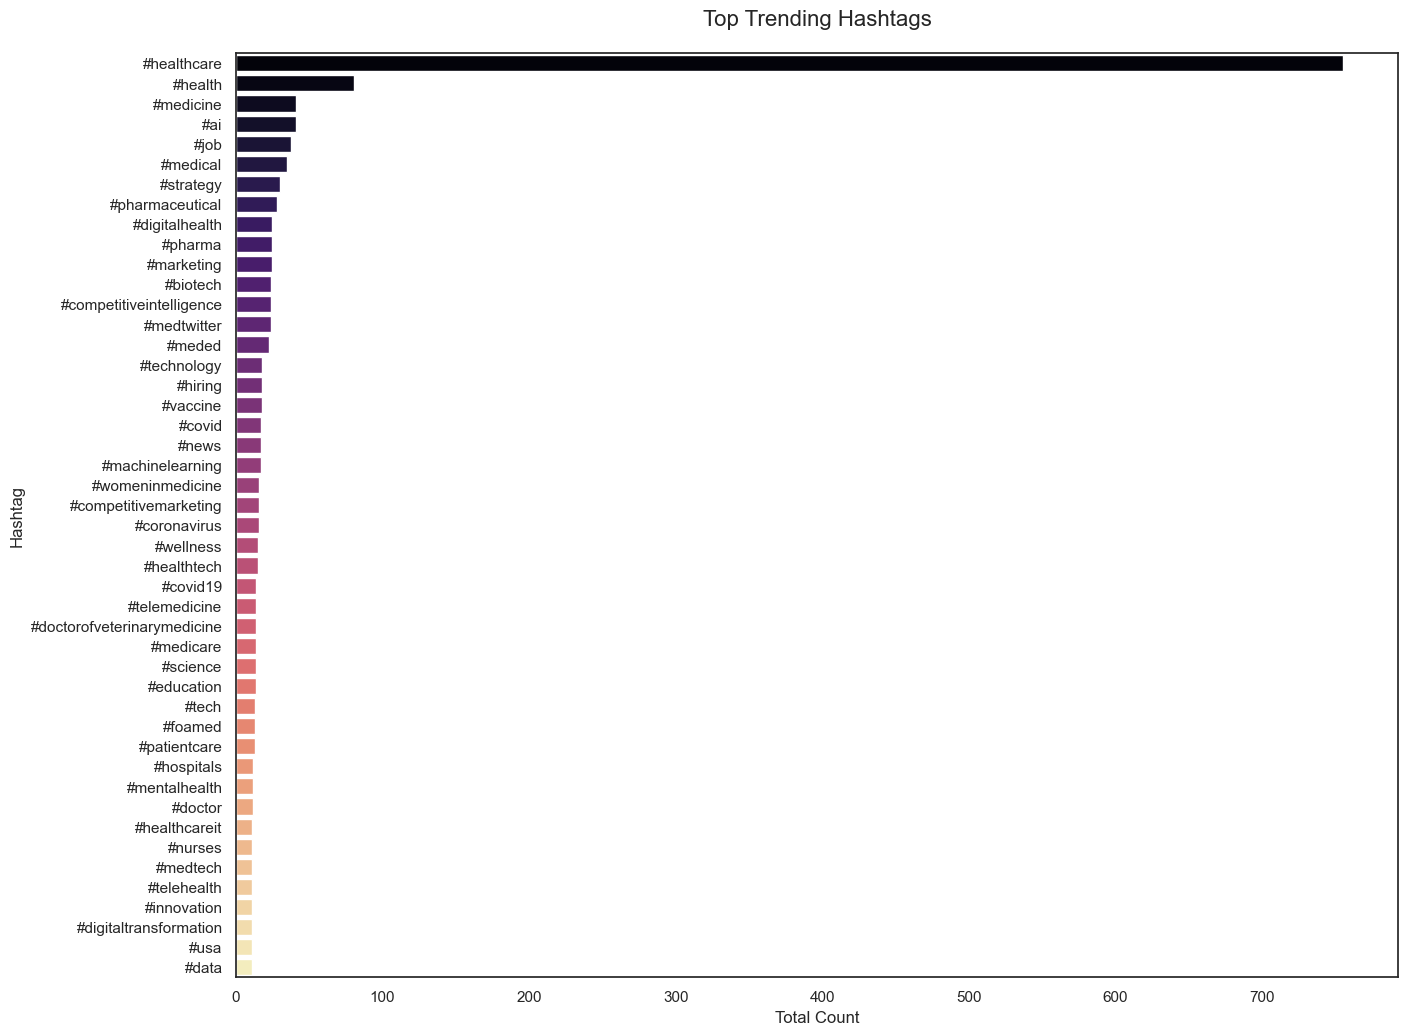

In [98]:
# Create the barplot for trending hashtags
plt.figure(figsize=(15,12))

sns.barplot(
    data=hashtag_count_10,
    x='count',
    y='word',
    palette='magma')

# Adding labels to the chart
plt.title('Top Trending Hashtags', fontsize=16, pad=20)
plt.xlabel('Total Count')
plt.ylabel('Hashtag')

plt.show()

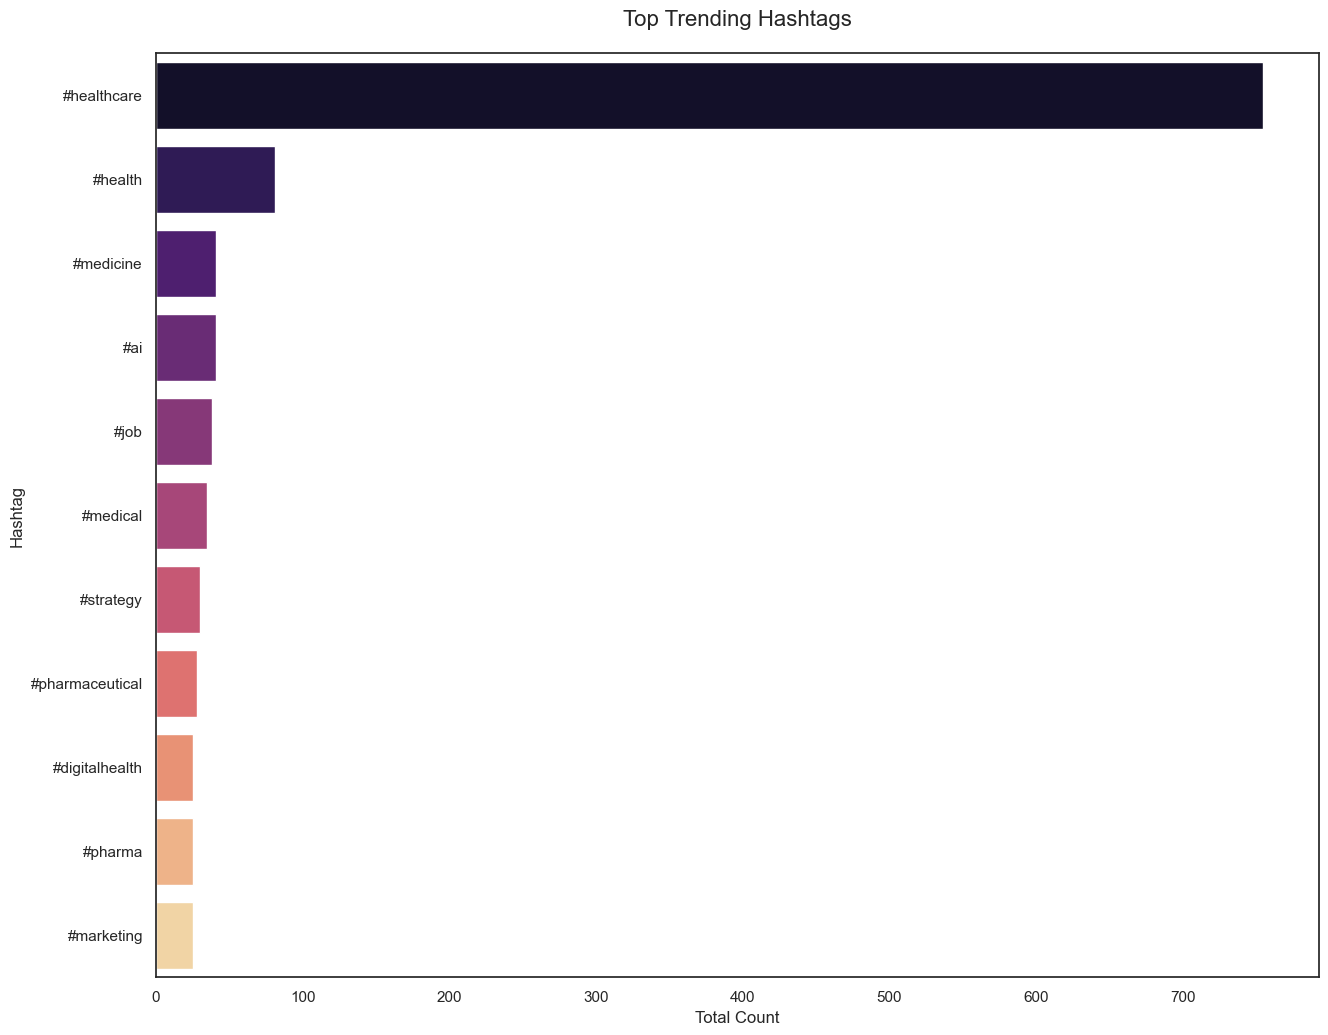

In [99]:
# Visualization improvements
"""The graph was quite big and I think showing top 11 hashtags is sufficient"""
hashtag_count_25 = twitter_data[twitter_data['count'] >= 25]

# Creating the bar plot
sns.barplot(
    data=hashtag_count_25,
    x='count',
    y='word',
    palette='magma')

# Adding labels to the chart
plt.title('Top Trending Hashtags', fontsize=16, pad=20)
plt.xlabel('Total Count')
plt.ylabel('Hashtag')

plt.show()